# Inspect Jingcheng's biophysical modeling results

In [4]:
import os
import json
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit
from scipy.ndimage import binary_opening, label

# ignore runtime warning
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Load data

*The path of the datasets is D:. Please change it according to the path where you save these datasets.*

In [2]:
def load_data(exp):
    root_folder_path = '/G/results/simulation/'
    # v_path = [root_folder_path, exp, 'dend_v_array.npy']
    # i_path = [root_folder_path, exp, 'dend_i_array.npy']
    # nmda_path = [root_folder_path, exp, 'dend_nmda_i_array.npy']
    # ampa_path = [root_folder_path, exp, 'dend_ampa_i_array.npy']
    
    # nmda_g_path = [root_folder_path, exp, 'dend_nmda_g_array.npy']
    # ampa_g_path = [root_folder_path, exp, 'dend_ampa_g_array.npy']
    
    # soma_path = [root_folder_path, exp, 'soma_v_array.npy']
    # apic_v_path = [root_folder_path, exp, 'apic_v_array.npy']
    # apic_ica_path = [root_folder_path, exp, 'apic_ica_array.npy']

    # v = np.load(os.path.join(*v_path))
    # i = np.load(os.path.join(*i_path))
    # nmda = np.load(os.path.join(*nmda_path))
    # ampa = np.load(os.path.join(*ampa_path))
    
    # nmda_g = np.load(os.path.join(*nmda_g_path))
    # ampa_g = np.load(os.path.join(*ampa_g_path))
    
    # soma = np.load(os.path.join(*soma_path))
    # apic_v = np.load(os.path.join(*apic_v_path))
    # apic_ica = np.load(os.path.join(*apic_ica_path))
    
    try:

        v_path = [root_folder_path, exp, 'dend_v_array.npy']
        i_path = [root_folder_path, exp, 'dend_i_array.npy']
        nmda_path = [root_folder_path, exp, 'dend_nmda_i_array.npy']
        ampa_path = [root_folder_path, exp, 'dend_ampa_i_array.npy']
        
        nmda_g_path = [root_folder_path, exp, 'dend_nmda_g_array.npy']
        ampa_g_path = [root_folder_path, exp, 'dend_ampa_g_array.npy']
        
        soma_path = [root_folder_path, exp, 'soma_v_array.npy']
        apic_v_path = [root_folder_path, exp, 'apic_v_array.npy']
        apic_ica_path = [root_folder_path, exp, 'apic_ica_array.npy']

        v = np.load(os.path.join(*v_path))
        i = np.load(os.path.join(*i_path))
        nmda = np.load(os.path.join(*nmda_path))
        ampa = np.load(os.path.join(*ampa_path))
        
        nmda_g = np.load(os.path.join(*nmda_g_path))
        ampa_g = np.load(os.path.join(*ampa_g_path))
        
        soma = np.load(os.path.join(*soma_path))
        apic_v = np.load(os.path.join(*apic_v_path))
        apic_ica = np.load(os.path.join(*apic_ica_path))
                                    
        trunk_v_path = [root_folder_path, exp, 'trunk_v_array.npy']
        basal_v_path = [root_folder_path, exp, 'basal_v_array.npy']
        tuft_v_path = [root_folder_path, exp, 'tuft_v_array.npy']

        basal_bg_i_nmda_path = [root_folder_path, exp, 'basal_bg_i_nmda_array.npy']
        basal_bg_i_ampa_path = [root_folder_path, exp, 'basal_bg_i_ampa_array.npy']
        tuft_bg_i_nmda_path = [root_folder_path, exp, 'tuft_bg_i_nmda_array.npy']
        tuft_bg_i_ampa_path = [root_folder_path, exp, 'tuft_bg_i_ampa_array.npy']

        trunk_v = np.load(os.path.join(*trunk_v_path))
        basal_v = np.load(os.path.join(*basal_v_path))
        tuft_v = np.load(os.path.join(*tuft_v_path))

        basal_bg_i_nmda = np.load(os.path.join(*basal_bg_i_nmda_path))
        basal_bg_i_ampa = np.load(os.path.join(*basal_bg_i_ampa_path))
        tuft_bg_i_nmda = np.load(os.path.join(*tuft_bg_i_nmda_path))
        tuft_bg_i_ampa = np.load(os.path.join(*tuft_bg_i_ampa_path)) 

    except FileNotFoundError:
        pass

    dt = 1/40000

    # read info from json and add to plot
    with open(os.path.join(root_folder_path, exp, 'simulation_params.json')) as f:
        simu_info = json.load(f)
    
    with open(os.path.join(root_folder_path, exp, 'section_synapse_df.csv')) as f:
        sec_syn_df = pd.read_csv(f)

    try:
        return v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, \
               trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
               tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df
    
    except NameError:
        return simu_info, sec_syn_df

### Functions

In [3]:
def count_subfolders(root_folder_path, exp):
    folder_path = os.path.join(root_folder_path, exp)
    all_items = os.listdir(folder_path)
    subfolders = [item for item in all_items if os.path.isdir(os.path.join(folder_path, item))]
    return len(subfolders)

def find_num_peaks(voltage_array):
    num_peaks = len(find_peaks(voltage_array, height=0)[0])
    return num_peaks

def find_longest_continuous_ones(bool_array):
    max_length = 0
    current_length = 0

    for value in bool_array:
        if value == 1:
            current_length += 1
            max_length = max(max_length, current_length)
        else:
            current_length = 0

    return max_length

# Create a Butterworth low-pass filter
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs  # 奈奎斯特频率
    normal_cutoff = cutoff / nyquist  # 归一化截止频率
    b, a = butter(order, normal_cutoff, btype='low', analog=False)  # 巴特沃斯低通滤波器
    return b, a

# Apply a Butterworth low-pass filter
def lowpass_filter(data, cutoff=50, fs=40000, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)  # 应用双向滤波器
    return y

def detect_nmda_spike(voltage_array):
    min_length = 26 * 40
    structure = np.ones(min_length)

    # 对序列进行形态学开运算
    opened_sequence = binary_opening(voltage_array, structure=structure).astype(int)

    # 对开运算后的序列进行标记，找到每个连续1的区段
    labeled_sequence, num_features = label(opened_sequence)

    # 找出每个特征区段的起始索引（onset）
    unique_labels, first_indices = np.unique(labeled_sequence, return_index=True)

    # 排除标签为0的部分（即非1的部分）
    onsets = first_indices[unique_labels != 0]

    t = 500
    spike_flag = 1 if np.any((onsets >= (t-30)*40) & (onsets <= (t+30)*40)) else 0

    return spike_flag

def detect_calcium_spike(voltage_array):
    min_length = 26 * 40
    structure = np.ones(min_length)

    opened_sequence = binary_opening(voltage_array, structure=structure).astype(int)
    labeled_sequence, num_features = label(opened_sequence)
    unique_labels, first_indices = np.unique(labeled_sequence, return_index=True)
    onsets = first_indices[unique_labels != 0]

    t = 500
    spike_flag = 1 if np.any((onsets >= (t-30)*40) & (onsets <= (t+100)*40)) else 0

    return spike_flag

def align_calcium_voltage_trace(apic_v, t_start, t_end, t_center):

    # align calcium
    # Assuming apic_v is your array with shape [40000, 40, 20]
    # Extract the 16000-24000 segment from the second dimension
    apic_v_segment = apic_v[t_start:t_end, :, :]  # Shape: [8000, 40, 20]

    # Find the peak index in the extracted segment
    peak_indices = np.argmax(apic_v_segment, axis=0)  # Shape: [40, 20]

    # Reference peak index (for the first trial in each cluster)
    peak_positions = peak_indices + t_start  # Shape: [40, 20]

    # Find peak values to check if they are greater than -40 mV
    peak_values = np.max(apic_v_segment, axis=0)  # Shape: [40, 20]

    # Mask for peaks greater than -40 mV
    valid_mask = peak_values > -40  # Shape: [40, 20]

    # Initialize an array to store the reference trial indices
    ref_trial_index = np.full(apic_v.shape[1], -1, dtype=int)  # Shape: [40]

    for epoch_idx in range(apic_v.shape[1]):
        valid_trials = np.where(valid_mask[epoch_idx])[0]
        if valid_trials.size > 0:
            closest_trial = valid_trials[np.argmin(np.abs(peak_positions[epoch_idx, valid_trials] - t_center))]
            ref_trial_index[epoch_idx] = closest_trial

    # 计算参考峰值位置
    ref_peak_positions = peak_positions[np.arange(apic_v.shape[1]), ref_trial_index]  # Shape: [40]

    # 计算滚动偏移量
    shifts = ref_peak_positions[:, np.newaxis] - peak_positions  # Shape: [40, 20]

    # 对于不满足条件的项，将 shift 设置为 0
    shifts[~valid_mask] = 0  # Shape: [40, 20]

    # 创建对齐后的结果数组
    aligned_apic_v = np.empty_like(apic_v)

    # 使用 np.roll 对满足条件的数据进行滚动
    for epoch_idx in range(apic_v_segment.shape[1]):
        for trial_idx in range(apic_v_segment.shape[2]):
            shift = int(shifts[epoch_idx, trial_idx])
            aligned_apic_v[:, epoch_idx, trial_idx] = np.roll(
                apic_v[:, epoch_idx, trial_idx], shift, axis=0
            )

    return aligned_apic_v

def mark_peaks(signal):
    peaks, _ = find_peaks(signal, height=0)
    peak_signal = np.zeros_like(signal)
    peak_signal[peaks] = 1
    return peak_signal

def soma_bin_peak(soma_segment, binsize=400, dt=1/40000):

    num_times = soma_segment.shape[0]
    num_affs = soma_segment.shape[1]
    num_bins = num_times // binsize

    ap_boolean = np.apply_along_axis(mark_peaks, axis=0, arr=soma_segment) # Shape: [num_times, num_affs, num_trials] 
    binned_ap_boolean = np.mean(ap_boolean.reshape(num_bins, binsize, num_affs, -1), axis=1) # Shape: [num_bins, num_affs, num_trials]

    # f = sum of spikes / (num_trials * duration)
    binned_firing_rate = np.mean(binned_ap_boolean, axis=-1) / dt # Shape: [num_times, num_affs] 
    peak_firing_rate = np.max(binned_firing_rate, axis=0)
    
    return peak_firing_rate

## Full visualization

In [5]:
def full_visualization(exp):
    try:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)
    
    except ValueError:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)

    if v.ndim == 5:
        v = np.mean(v, axis=2) # shape: [num_clusters, num_times, num_affs, num_trials]
        soma = np.mean(soma, axis=1) # shape: [num_times, num_affs, num_trials]
        apic_v = np.mean(apic_v, axis=1) # shape: [num_times, num_affs, num_trials]

    dis_to_root = simu_info['distance from clusters to root']
    num_stim = simu_info['number of stimuli']

    t = simu_info['time point of stimulation']
    t_start = t*40-10000
    t_end = t*40+10000
    t_vals = np.arange(t_start, t_end)*dt-t/1000
    syn_num = v.shape[2]
    fig, ax = plt.subplots(1,1+syn_num//2,figsize=((1+syn_num//2)*2,8),sharey=True)

    plt.suptitle(exp+f' order to root: {dis_to_root}, number of stimuli: {num_stim})')
    fig.subplots_adjust(wspace=0)

    for i in range(0, syn_num, 2):
        ax[i//2].plot(t_vals, np.average(v[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(v.shape[0])*100)
        ax[i//2].plot(t_vals, np.average(soma[t_start:t_end, i, :],axis=1).squeeze()-100, color='k')
        ax[i//2].plot(t_vals, np.average(apic_v[t_start:t_end, i, :],axis=1).squeeze()-200, color='b')
        # add red dash line between (t-20)*40 and (t+20)*40
        ax[i//2].axvline(x=-20/1000, color='r', linestyle='--', alpha=0.5)
        ax[i//2].axvline(x=20/1000, color='r', linestyle='--', alpha=0.5)

        # ax[i].plot(t_vals, 1000*np.average(nmda[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(v.shape[0])*100,color='r')
        # ax[i].plot(t_vals, 1000*np.average(ampa[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(v.shape[0])*100,color='b')
        # ax[i].plot(t_vals, v[:, t_start:t_end, i, run_num].squeeze().T+np.arange(20)*100)
        # ax[i].plot(t_vals, soma[t_start:t_end, i, run_num].squeeze()-100, color='k')
        ax[i//2].set_yticks([])
        ax[i//2].set_xlabel('Time (s)')
        
        if i == 0:  # Add label only for the first subplot
            ax[i//2].text(-0.1,0.06,'Ca', transform=ax[i].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')
            ax[i//2].text(-0.2,0.2,'Soma', transform=ax[i].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')
            for j in range(v.shape[0]):
                # ax[i].text(-0.1, 0.1+j*0.045, str(j+1), transform=ax[i].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')
                ax[i//2].text(-0.1,0.35+j*(0.74*1/v.shape[0]), str(j+1), transform=ax[i].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')

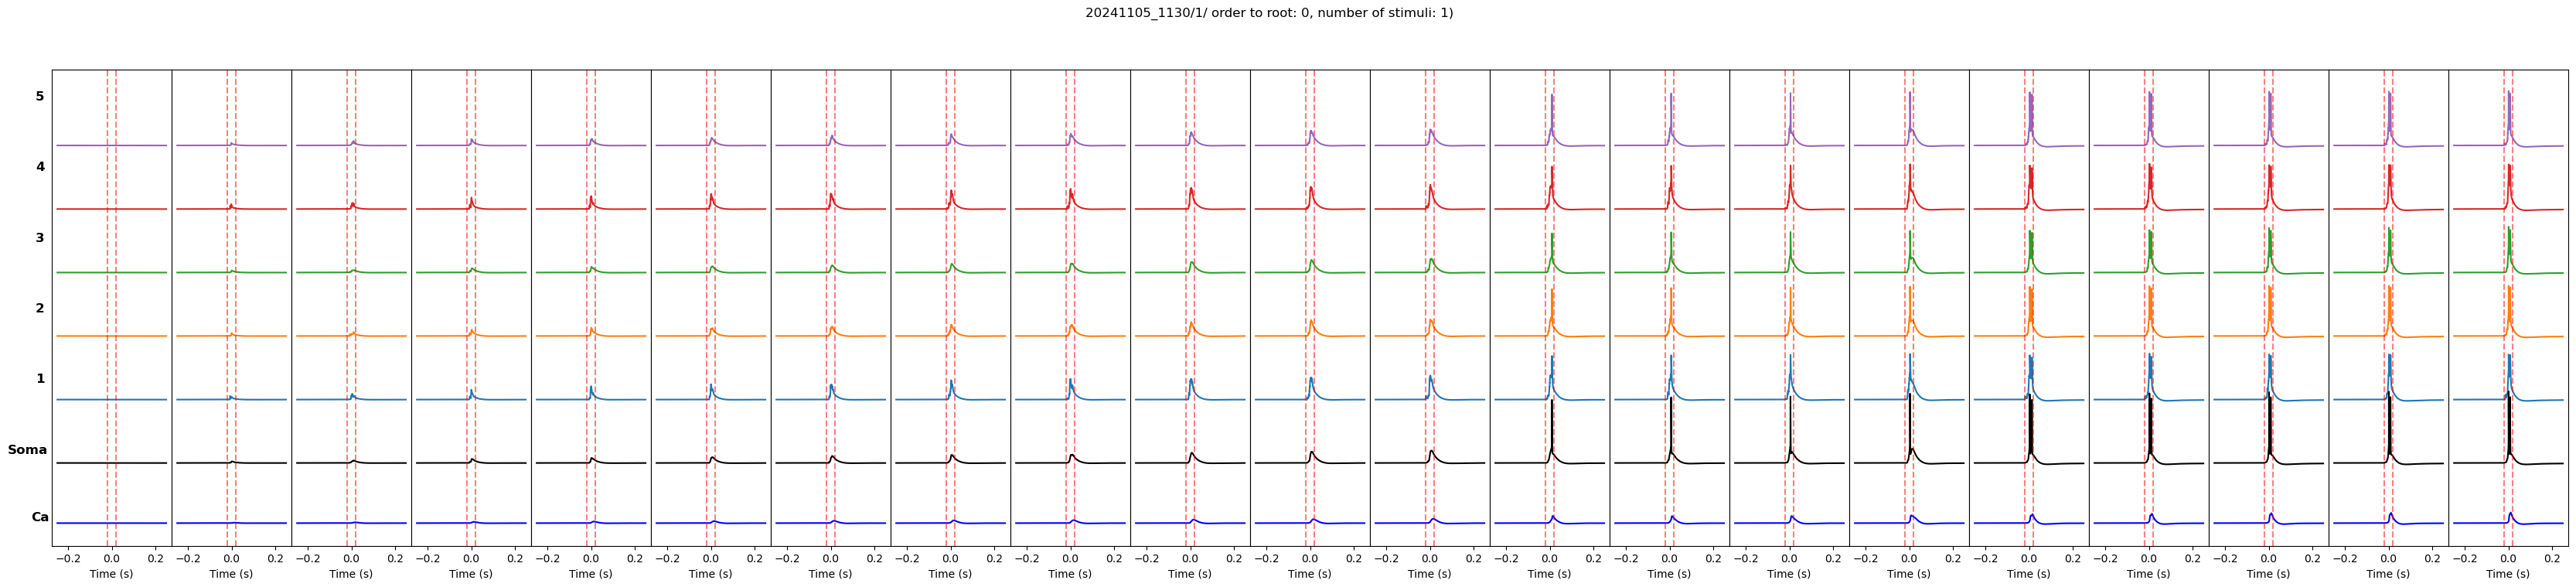

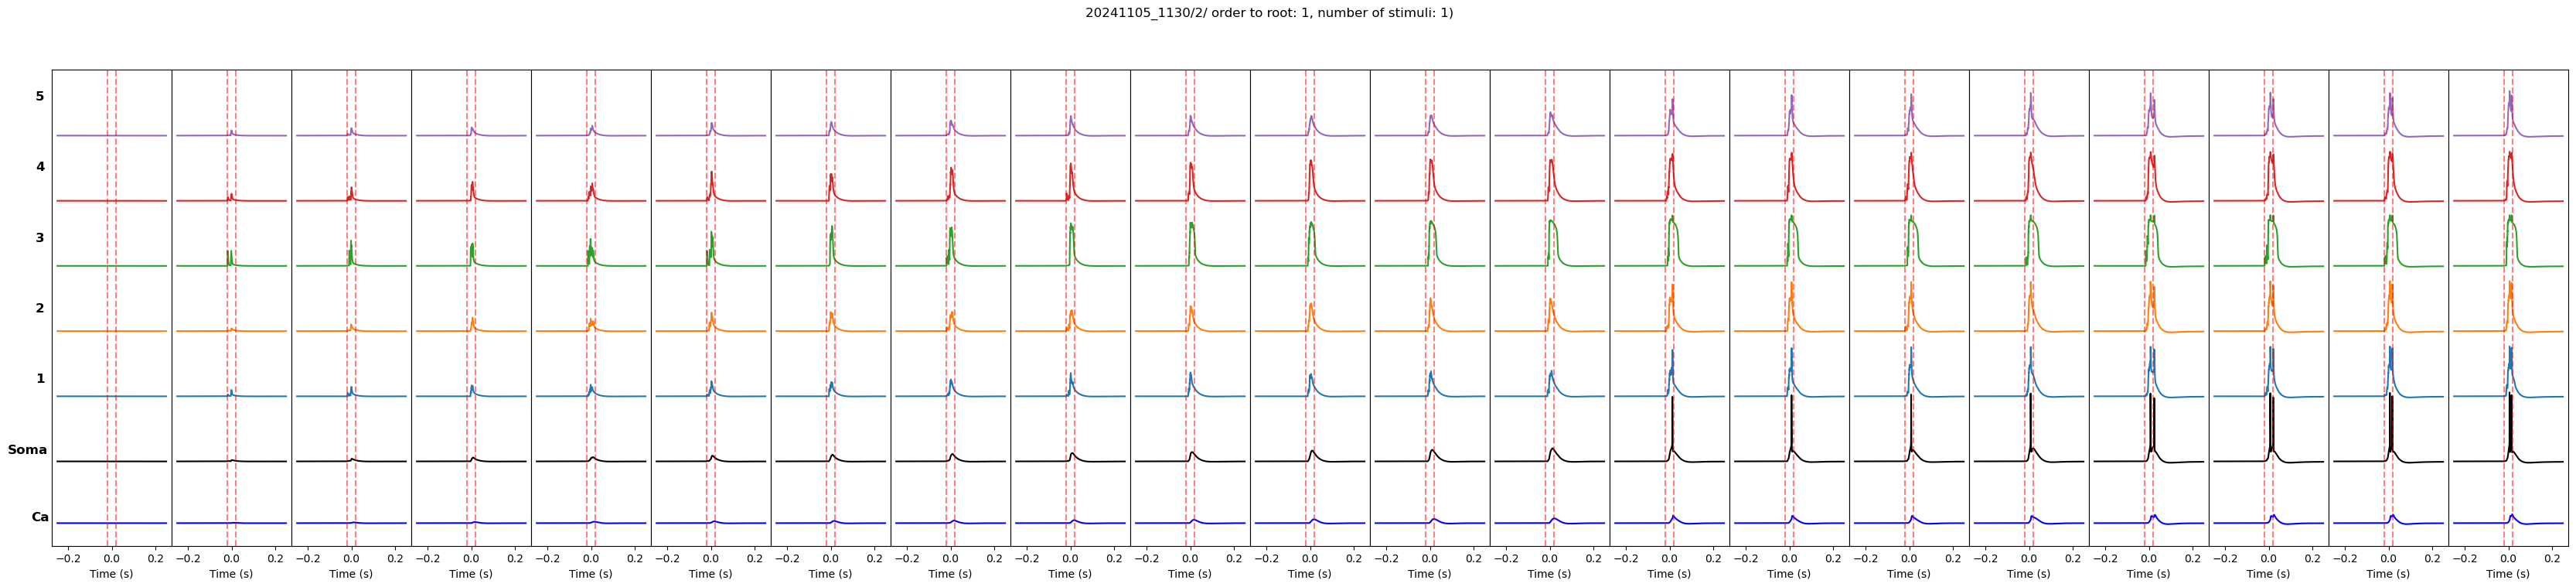

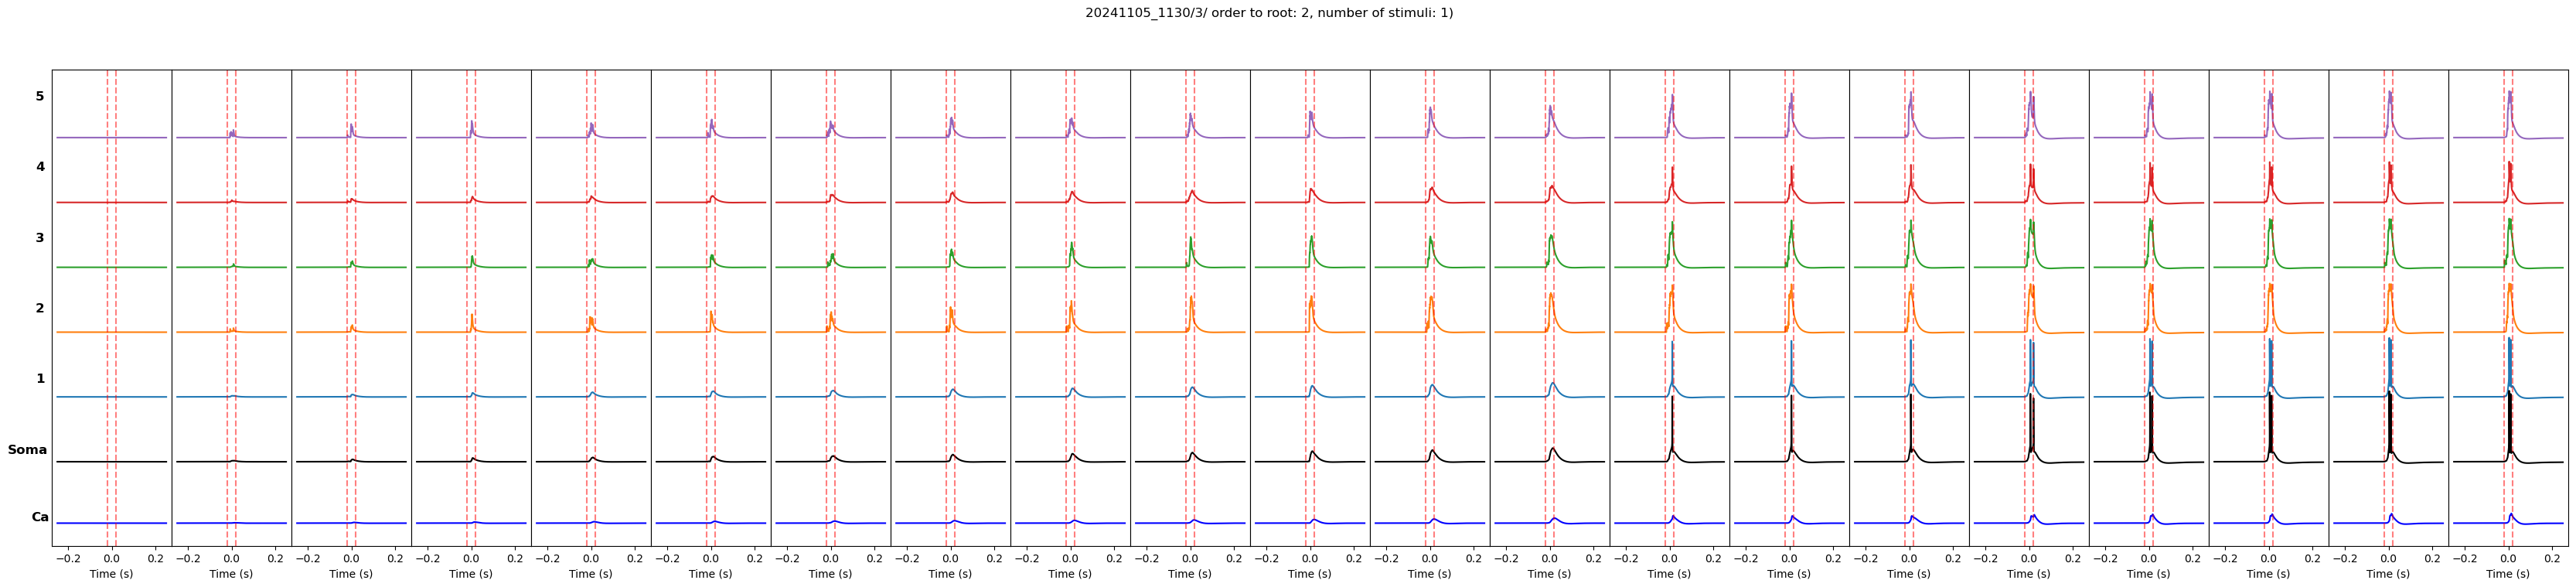

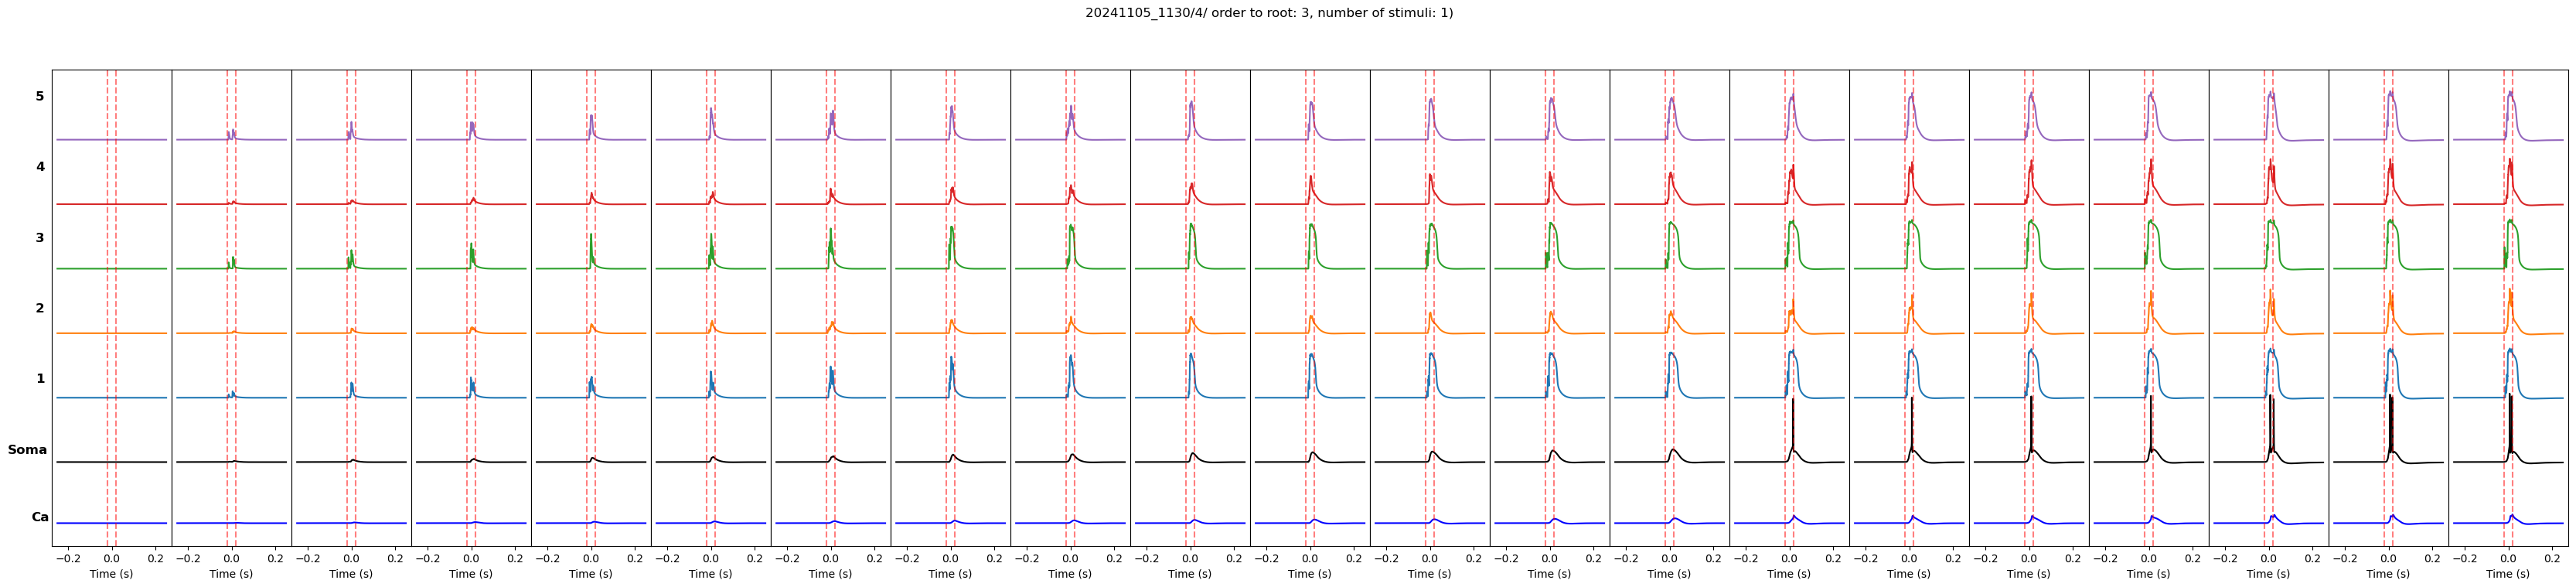

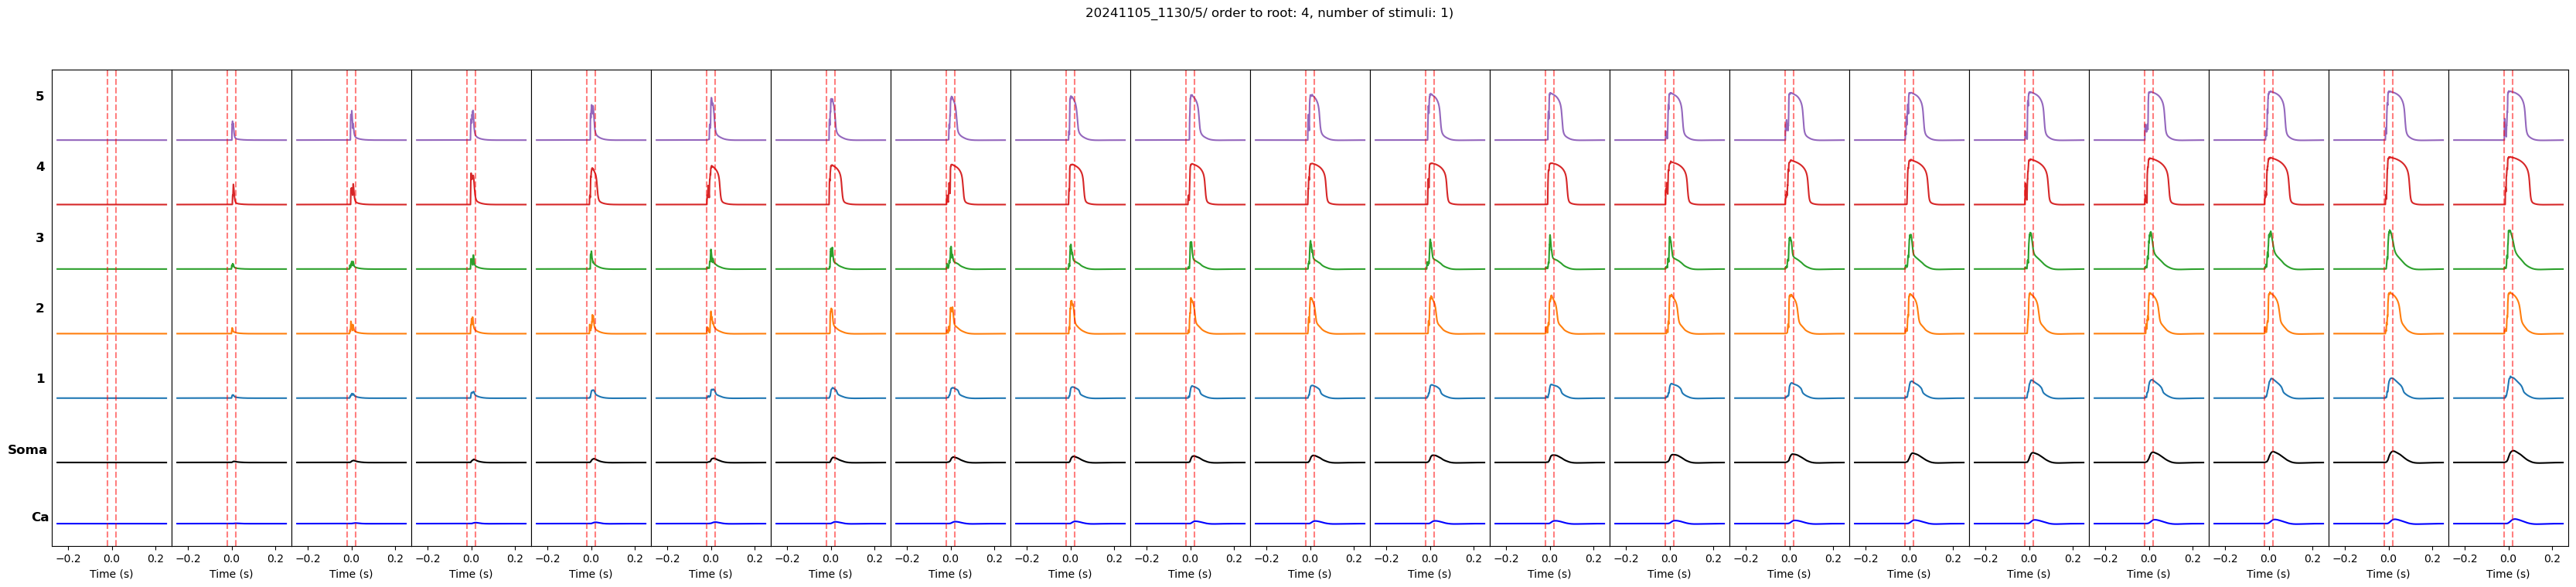

In [15]:
full_visualization('20241105_1130/1/')
full_visualization('20241105_1130/2/')
full_visualization('20241105_1130/3/')
full_visualization('20241105_1130/4/')
full_visualization('20241105_1130/5/')

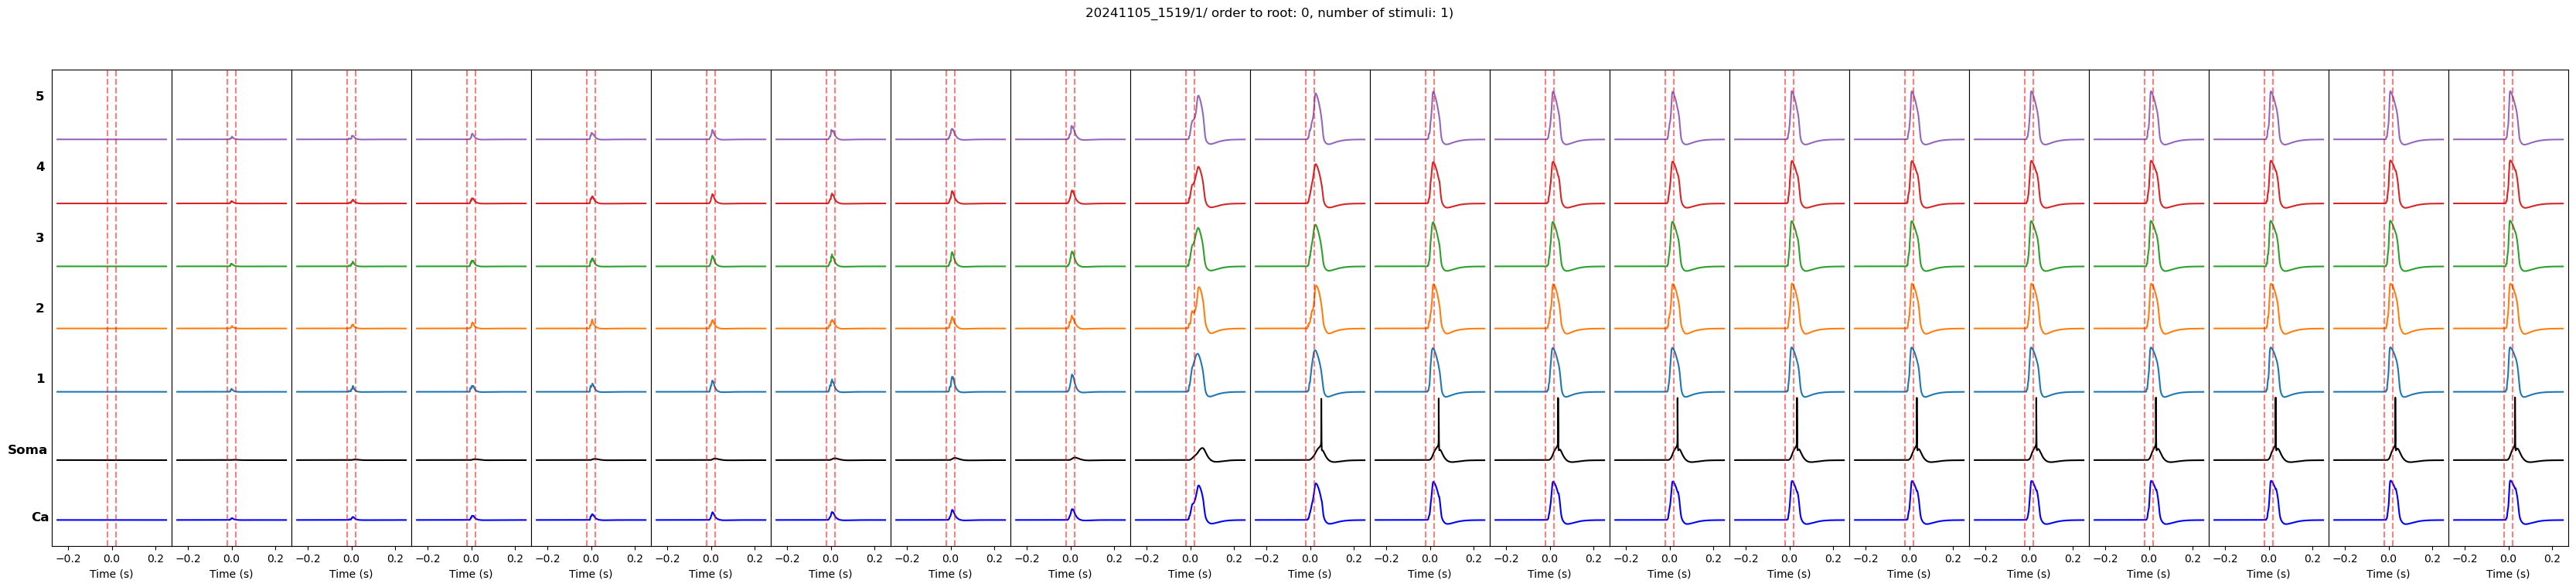

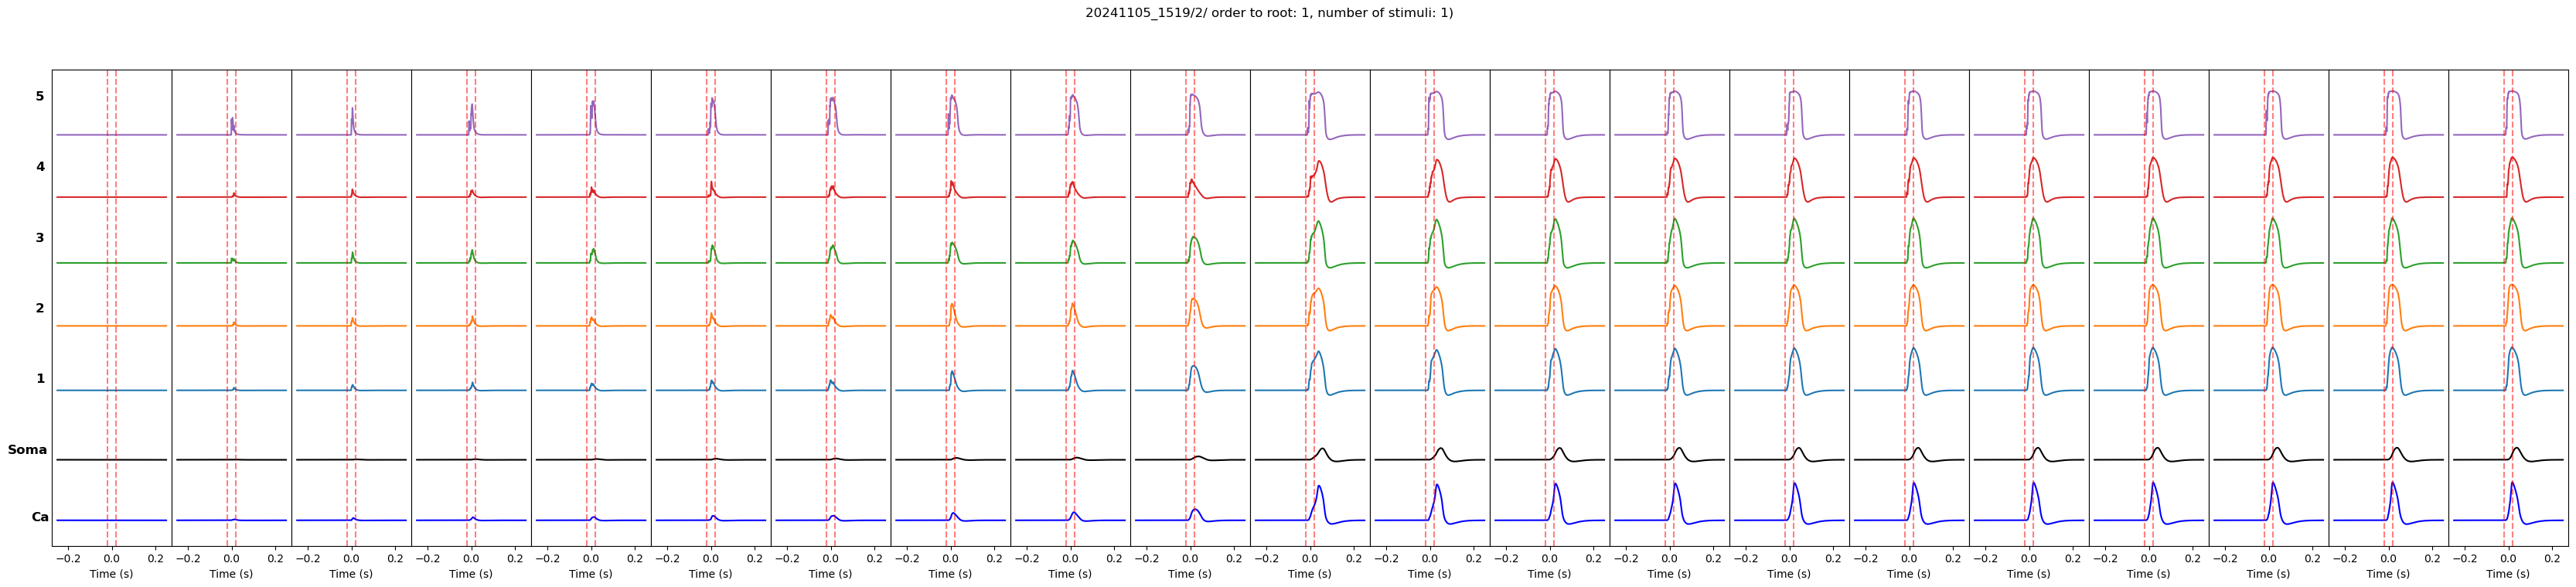

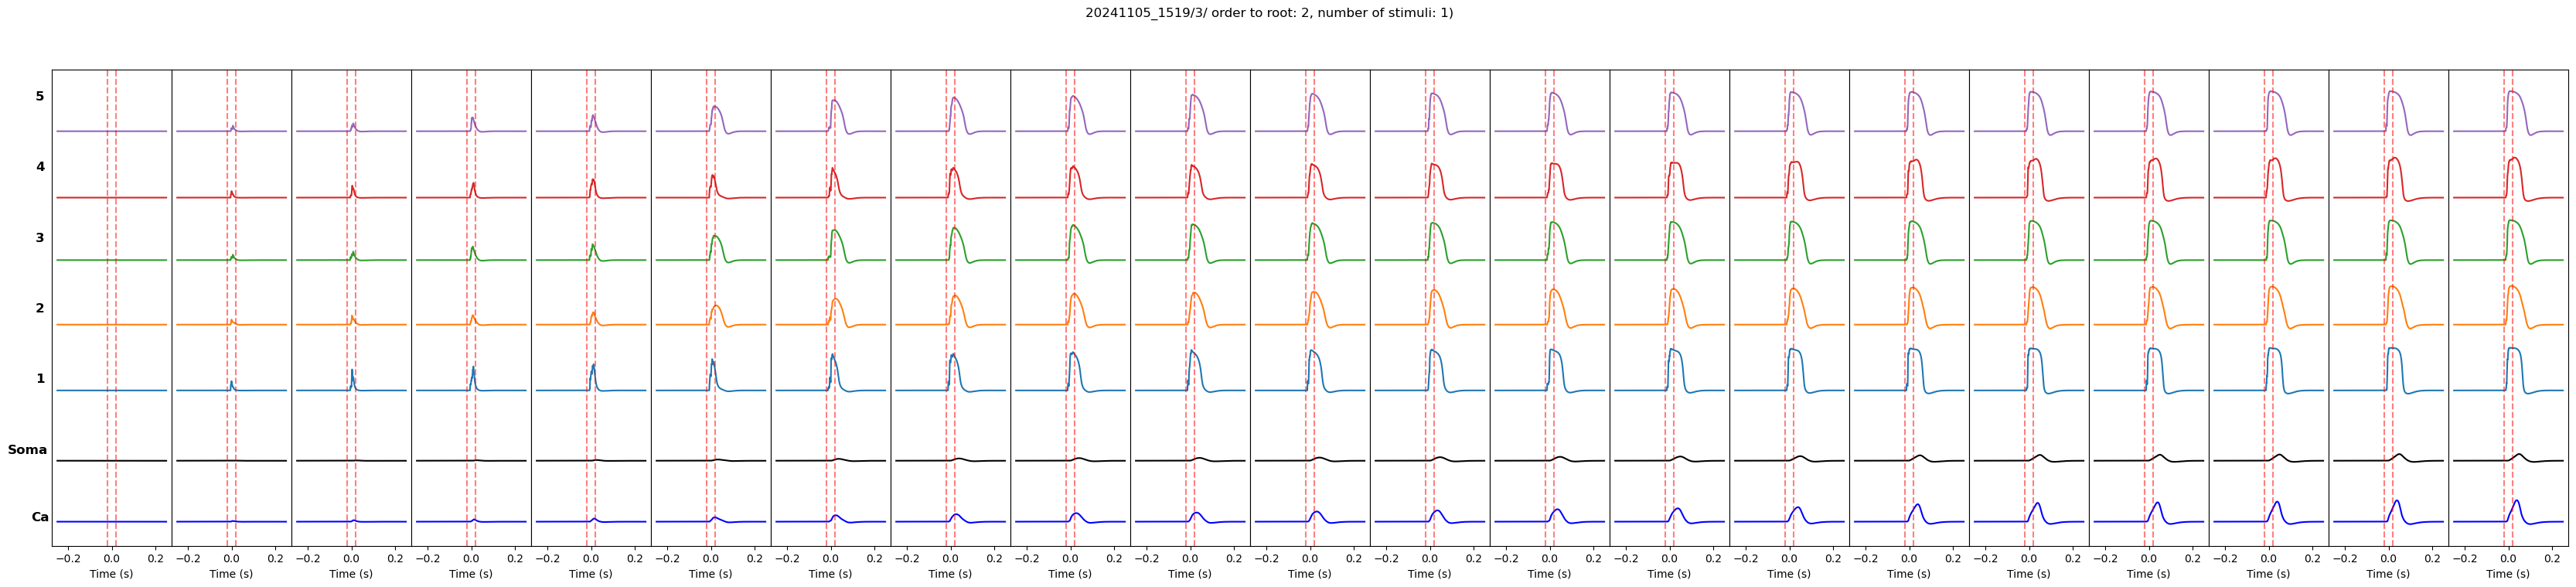

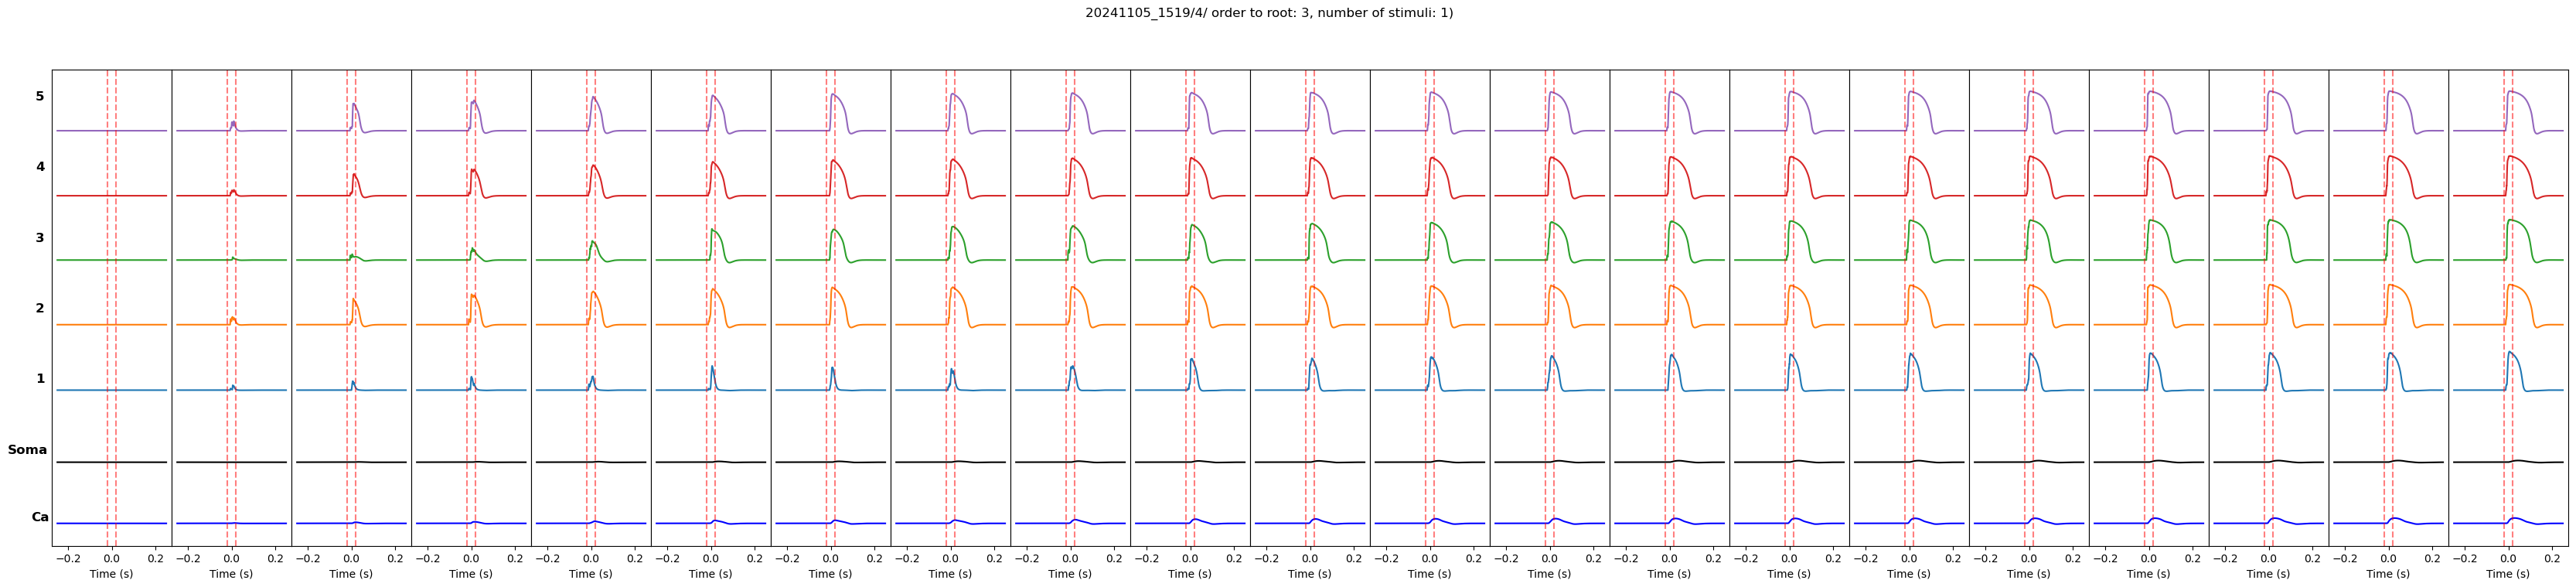

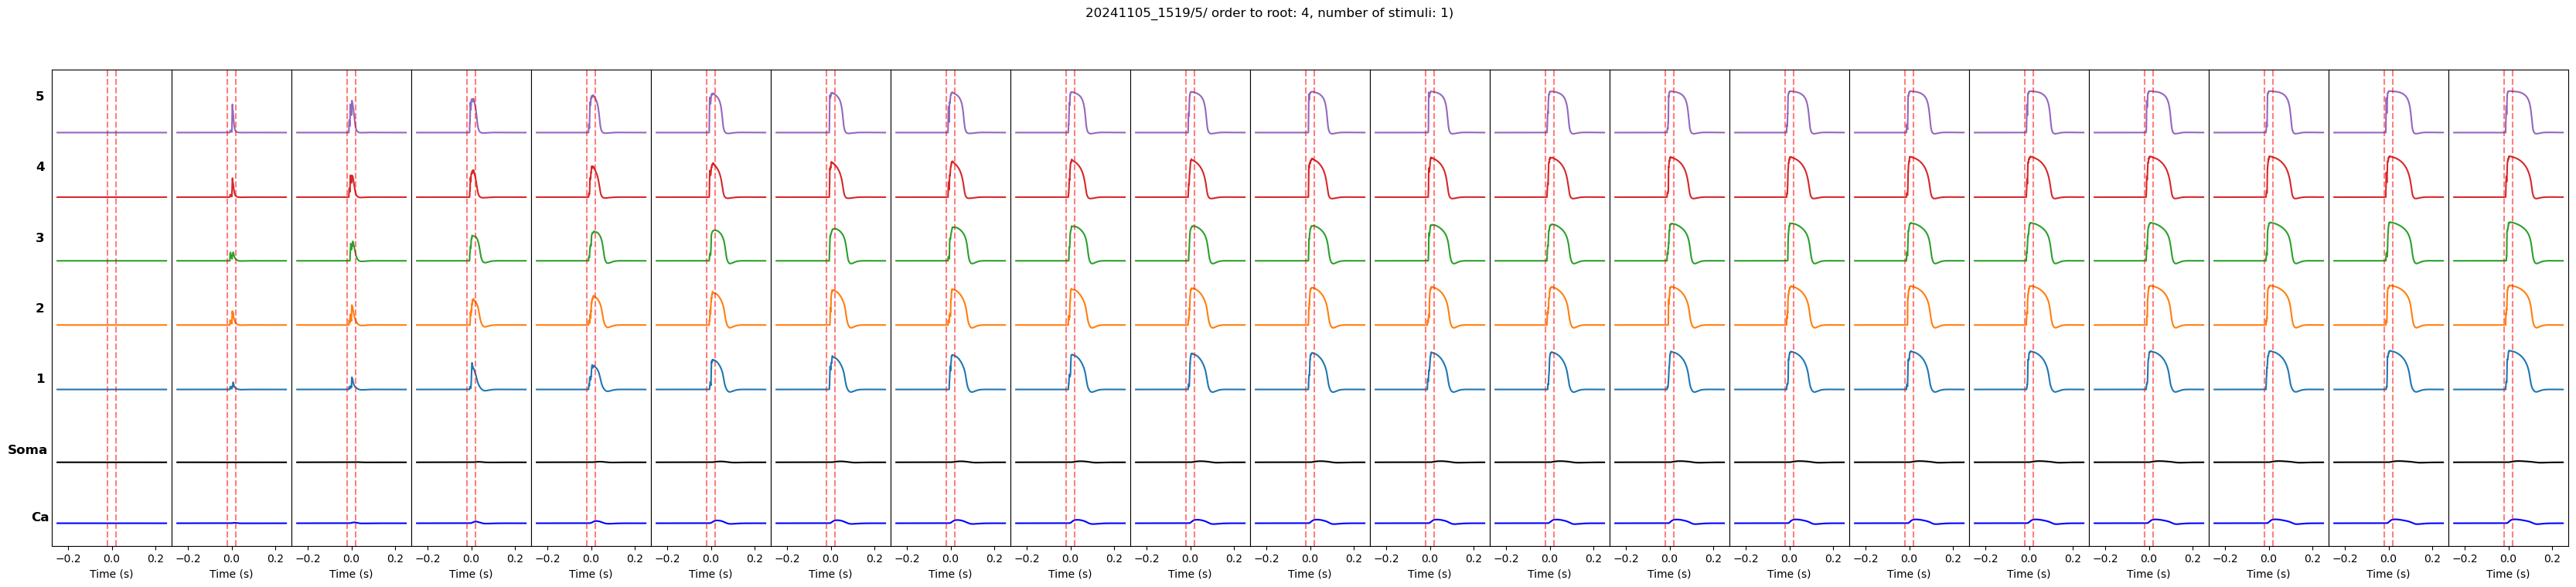

In [18]:
full_visualization('20241105_1519/1/')
full_visualization('20241105_1519/2/')
full_visualization('20241105_1519/3/')
full_visualization('20241105_1519/4/')
full_visualization('20241105_1519/5/')

### Volatge superposition

In [388]:
def volatge_superposition(exp):
    try:
        v, i, nmda, ampa, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)

    except ValueError:
        v, i, nmda, ampa, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)

    if v.ndim == 5:
        v = np.mean(v, axis=2) # shape: [num_clusters, num_times, num_affs, num_trials]
        soma = np.mean(soma, axis=1) # shape: [num_times, num_affs, num_trials]

    dis_to_root = simu_info['distance from clusters to root']
    num_stim = simu_info['number of stimuli']

    t = simu_info['time point of stimulation']
    t_start = (t - 200) * 40
    t_end = (t + 200) * 40
    t_vals = np.arange(t_start, t_end)*dt-t/1000
    
    clus_idxs = [0,1,2,3,4]
    clus_ctr_syn = sec_syn_df[sec_syn_df['is_cluster_center']==1]['segment_synapse'].values
    clus_ctr_dis = np.round(sec_syn_df[sec_syn_df['is_cluster_center']==1]['cluster_distance'].values,2)

    num_affs = v.shape[2]
    fig, ax = plt.subplots(1,v.shape[0],figsize=(v.shape[0]*10,10))
    plt.suptitle(exp+f' order to root: {dis_to_root}, number of stimuli: {num_stim}',y=1.05)
    for clus_idx in clus_idxs:
        fig.subplots_adjust(wspace=0)
        for aff_idx in range(0, num_affs, 4):
            # ax.plot(t_vals, np.average(v[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(20)*100,linewidth=0.8)
            ax[clus_idx].plot(t_vals, np.average(v[clus_idx, t_start:t_end, aff_idx, :],axis=1).squeeze().T,linewidth=0.8)
            ax[clus_idx].plot(t_vals, np.average(soma[t_start:t_end, aff_idx, :],axis=1).squeeze()-100, linewidth=0.8)
            # ax[i].plot(t_vals, v[:, t_start:t_end, i, run_num].squeeze().T+np.arange(20)*100)
            # ax[i].plot(t_vals, soma[t_start:t_end, i, run_num].squeeze()-100, color='k')
            ax[clus_idx].set_yticks([])
            ax[clus_idx].set_xlabel('Time(s)')
            ax[clus_idx].set_title(f'Cluster {clus_idx+1}, Distance: {clus_ctr_dis[clus_idx]}\n{clus_ctr_syn[clus_idx]}')
            if clus_idx == 0:
                ax[clus_idx].text(-0.1,0.7,'Cluster', transform=ax[clus_idx].transAxes, va='center', ha='center', fontsize=10, fontweight='bold')
                ax[clus_idx].text(-0.1,0.15,'Soma', transform=ax[clus_idx].transAxes, va='center', ha='center', fontsize=10, fontweight='bold')            

In [579]:
def single_volatge_superposition(exp):
    
    try:
        v, i, nmda, ampa, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)

    except ValueError:
        v, i, nmda, ampa, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)
        
    if v.ndim == 5:
        v = np.mean(v, axis=2)
    
    # Low-pass filt v
    v = np.apply_along_axis(lowpass_filter, axis=1, arr=v) # shape: [num_clusters, num_times, num_affs, num_trials]

    num_preunit = simu_info['number of preunit']
    num_aff_fibers = v.shape[2]
    num_affrents = np.linspace(0, num_preunit, num_aff_fibers) # np.arange(0, num_preunit+5, 5)

    t = simu_info['time point of stimulation']
    t_start = (t - 50) * 40
    t_end = (t + 200) * 40
    t_vals = np.arange(t_start, t_end)*dt-t/1000

    clus_ctr_syn = sec_syn_df[sec_syn_df['is_cluster_center']==1]['segment_synapse'].values
    clus_ctr_dis = np.round(sec_syn_df[sec_syn_df['is_cluster_center']==1]['cluster_distance'].values,2)

    V_DUR_THR, nmda_amp_thr = 26, -40
    
    nmda_baseline = np.mean(v[:, (t-200)*40:(t-100)*40, :, :])
    
    nmda_clus_baseline_list = []
    plt.figure(figsize=(40, 4))
    for clus_idx in range(5):

        # nmda_positive = np.clip(np.mean(v[clus_idx, t_start:t_end, :, :], axis=2) - nmda_amp_thr, 0, None)
        # # nmda_positive = np.clip(np.mean(v[clus_idx, t_start:t_end, :, :], axis=2) - nmda_baseline, 0, None)
        # area_nmda_spikes = np.trapz(nmda_positive, x, axis=0)
        
        nmda_above_threshold_bools_array = v[clus_idx, t_start:t_end, :, :] > nmda_amp_thr # shape: (num_time, num_aff, num_trials)
        prob_nmda_spikes = np.mean(np.apply_along_axis(detect_nmda_spike, axis=0, arr=nmda_above_threshold_bools_array), axis=1) # shape: (num_aff)
        
        nmda_over_baseline = np.clip(np.mean(v[clus_idx, t_start:t_end, :, :], axis=2) - nmda_baseline, 0, None) # shape: (num_time, num_aff)
        peak_nmda_spikes = np.max(nmda_over_baseline, axis=0) # shape: (num_aff)

        t_start = (t - 50) * 40
        t_end = (t + 200) * 40
        t_vals = np.arange(t_start, t_end)*dt-t/1000

        nmda_clus_baseline_list.append(round(np.mean(v[clus_idx, (t-200)*40:(t-100)*40, :, :]), 2))
        
        # plt.figure(figsize=(15,7))
        
        plt.subplot(1,10,clus_idx*2+1)
        plt.ylim(-80,10)
        plt.xticks(fontsize=15)
        if clus_idx == 0:
            plt.ylabel('Voltage (mV)', fontsize=15)
            plt.yticks([-70, -50, -30, -10, 10], fontsize=15)
        else:
            plt.yticks([])
        # plt.xlabel('Time from afferent burst peak (ms)', fontsize=15)
        plt.xlabel('Time (ms)', fontsize=15)
        # remove top and right
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title(f'Cluster distance to soma: {clus_ctr_dis[clus_idx]}\n{clus_ctr_syn[clus_idx]}')
        colors = ['#29ABE2', '#006837', '#009245', '#39B54A', '#8CC63F', '#D9E021', '#FCEE21', '#FBB03B', '#F7931E', '#F15A24', '#ED1C24']
        # for clus_idx in clus_idxs:
        plt.plot(1000*t_vals, nmda_amp_thr*np.ones_like(t_vals), color='k', linestyle='--', label='NMDA Threshold')
        for i in range(0, num_aff_fibers, 4):
            # print(f'{i} nmda length: {round(1/40 * np.mean(np.sum(nmda_above_threshold_bools_array[:, i, :],axis=0)), 2)}')
            plt.plot(1000*t_vals, np.average(v[clus_idx, t_start:t_end, i, :],axis=1).squeeze().T,linewidth=0.8, color=colors[i//4])
                
        ax1 = plt.subplot(1,10,clus_idx*2+2)
        ax1.spines['top'].set_visible(False)
        ax1.set_yticks([0, 20, 40, 60, 80]) # for ax, it's not allowed to adjust the fontsize through set_yticks
        ax1.set_xticks([0, 20, 40, 60, 80])
        ax1.tick_params(axis='y', color='#2C358D', labelcolor='k')
        ax1.tick_params(axis='both', labelsize=15, width=1.5)
        ax1.set_xlabel('Number of activated afferents', fontsize=15)
        ax1.set_ylabel('Amplitude of NMDA spike (mV)', fontsize=15)
        ax1.set_ylim(-0.005, 80.005)
        ax1.plot(num_affrents, peak_nmda_spikes, color='#2C358D', label='NMDA spike amplitude')

        ax2 = ax1.twinx()
        ax2.spines['left'].set_color('#2C358D')
        ax2.spines['right'].set_color('#C6252A')
        ax2.spines['left'].set_linewidth(2)
        ax2.spines['right'].set_linewidth(2)
        ax2.tick_params(axis='y', labelsize=15, width=1.5)
        ax2.tick_params(axis='y', color='#C6252A', labelcolor='k')
        ax2.spines['top'].set_visible(False)
        ax2.set_ylabel('Probability of NMDA spike', fontsize=15)
        ax2.plot(num_affrents, prob_nmda_spikes, color='#C6252A', label='P(NMDA spike)')
        ax2.set_ylim(-0.005, 1.005)

    # create path
    # if not os.path.exists(f'D:/results/simulation/pseudo/figures/{exp}'):
    #     os.makedirs(f'D:/results/simulation/pseudo/figures/{exp}')

    # plt.savefig(f'D:/results/simulation/pseudo/figures/{exp}clus_{clus_idx} example overlap_sparse.pdf')

    print(f'Voltage baseline: {nmda_clus_baseline_list}')

In [127]:
for exp in ['20241017_1533/1/', '20241017_1533/2/', '20241017_1533/3/', '20241017_1533/4/', \
            '20241017_1533/5/', '20241017_1533/6/', '20241017_1533/7/', '20241017_1533/8/']:
    try:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)

    except ValueError:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)

    if v.ndim == 5:
        v = np.mean(v, axis=2)
        nmda = np.mean(nmda, axis=2)
        nmda_g = np.mean(nmda_g, axis=2)
        ampa_g = np.mean(ampa_g, axis=2)
        apic_v = np.mean(apic_v, axis=1)
        soma = np.mean(soma, axis=1)

    sec_type = simu_info['section type'] 
    simu_condition = simu_info['simulation condition']
    dis_to_root = simu_info['distance from clusters to root']

    t = simu_info['time point of stimulation']
    t_start = (t-50)*40
    t_end = (t+200)*40
    t_vals = np.arange(t_start, t_end)*dt-t/1000

    num_affs = v.shape[2]
    num_clus = v.shape[0]

    num_epochs = num_clus * 3
    width = 15 * num_clus * 3
    height = 15
    
    step = 4

    print(sec_type, simu_condition, dis_to_root)
    print(f'{np.max(nmda_g):.2e}', f'{np.max(ampa_g):.2e}')
    print(f'{np.min(nmda):.2e}', f'{np.min(ampa):.2e}')

    colors_red = cm.Reds(np.linspace(0.2, 1, num_affs//step+1)) 
    colors_blue = cm.Blues(np.linspace(0.2, 1, num_affs//step+1)) 
    
    plt.figure(figsize=(width, height))
    # plt.suptitle(exp)

    for num_epoch in range(num_epochs):
        # plt.subplot(num_affs//step+1, num_epochs, aff_idx//step*num_epochs+num_epoch+1)
        plt.subplot(1, num_epochs, num_epoch+1)
        plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)  # Remove y-ticks and labels
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Remove x-ticks and labels

        if (num_epoch % 3 == 0):
            plt.annotate(f'Clus {num_epoch//3+1} Voltage', xy=(0.5, 1.1), xycoords='axes fraction', ha='center', va='center', fontsize=width*0.4)
        elif (num_epoch % 3 == 1):
            plt.annotate(f'NMDA Current', xy=(0.5, 1.1), xycoords='axes fraction', ha='center', va='center', fontsize=width*0.4)
        else:
            plt.annotate(f'NMDA Conductance', xy=(0.5, 1.1), xycoords='axes fraction', ha='center', va='center', fontsize=width*0.4)

        # if aff_idx != num_affs - 1:
            # plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Remove x-ticks and labels

        # if num_epoch == 0:
            # plt.ylabel(aff_idx+1)

        for aff_idx in range(0, num_affs, step):
            if num_epoch % 3 == 0:
                plt.ylim(-80,20)
                plt.plot(1000*t_vals, -40*np.ones_like(t_vals), color='k', linestyle='--', label='Voltage Threshold')
                plt.plot(1000*t_vals, v[num_epoch//3, t_start:t_end, aff_idx, :5].squeeze(), alpha=0.9)

                # # plt.ylim(np.min(nmda_g)-0.01*np.max(nmda_g), 1.01*np.max(nmda_g))
                # plt.ylim(-1e-5, 2.5e-4)
                # plt.plot(1000*t_vals, np.average(ampa_g[num_epoch//2, t_start:t_end, aff_idx, :],axis=1).squeeze(), alpha=0.9)
                # plt.plot(1000*t_vals, ampa_g[num_epoch//2, t_start:t_end, aff_idx, :5].squeeze(), alpha=0.9, color=colors_red[aff_idx//step])

            elif num_epoch % 3 == 1:
                plt.ylim(-2.2e-3, 1e-4)
                plt.plot(1000*t_vals, np.average(nmda[num_epoch//3, t_start:t_end, aff_idx, :],axis=1).squeeze(), alpha=0.9)
                plt.plot(1000*t_vals, nmda[num_epoch//3, t_start:t_end, aff_idx, :5].squeeze(), alpha=0.9, color=colors_red[aff_idx//step])

            else:

                # if sec_type == 'apical':
                #     plt.plot(1000*t_vals, -40*np.ones_like(t_vals), color='k', linestyle='--', label='Voltage Threshold')
                #     plt.plot(1000*t_vals, apic_v[t_start:t_end, aff_idx, :5].squeeze(), alpha=0.4)
                # elif sec_type == 'basal':
                #     plt.plot(1000*t_vals, soma[t_start:t_end, aff_idx, :5].squeeze(), alpha=0.4)

                # plt.ylim(np.min(nmda_g)-0.01*np.max(nmda_g), 1.01*np.max(nmda_g))
                plt.ylim(-1e-5, 2.5e-4)
                plt.plot(1000*t_vals, np.average(nmda_g[num_epoch//3, t_start:t_end, aff_idx, :],axis=1).squeeze(), alpha=0.9)
                plt.plot(1000*t_vals, nmda_g[num_epoch//3, t_start:t_end, aff_idx, :5].squeeze(), alpha=0.9, color=colors_blue[aff_idx//step])
            
    plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: '/G/results/simulation/20240924_1052/1/dend_v_array.npy'

In [55]:
def visualization(exp, fig_idx, stim_num, trial_idx):
    try:
        v, i, nmda, ampa, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)
    
    except ValueError:
        v, i, nmda, ampa, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)
    
    dis_to_root = simu_info['distance from clusters to root']
    num_stim = simu_info['number of stimuli']

    t = simu_info['time point of stimulation']
    t_start = t*40-2000
    t_end = t*40+2000
    t_vals = np.arange(t_start, t_end)*dt
    syn_num = 0
    clus_idx = 0
    
    plt.figure(fig1.number)
    plt.subplot(2, 3, stim_num*3+1)
    plt.ylim(-80,-50)
    plt.plot(1000*t_vals, v[clus_idx, t_start:t_end, stim_num, syn_num, trial_idx].squeeze(), alpha=1, color='b', 
                label=f'Stim number: {stim_num+1}', linewidth=2)
    plt.ylabel('Voltage (mV)')
    if stim_num == 0:
        plt.title('Voltage Response')
    plt.legend(fontsize=10, loc='upper left')

    plt.subplot(2, 3, stim_num*3+2)
    plt.ylim(-2, 0.05)    
    plt.plot(1000*t_vals,1000*nmda[clus_idx, t_start:t_end, stim_num, syn_num, trial_idx].squeeze(), alpha=1, color='c', 
             label=f'Stim num: {stim_num+1}', linewidth=2)
    plt.ylabel('Current (pA)')
    if stim_num == 0:
        plt.title('NMDA Current Response')
    plt.legend(fontsize=10, loc='upper left')

    plt.subplot(2, 3, stim_num*3+3)
    plt.ylim(-25, 0.5)
    plt.plot(1000*t_vals,1000*ampa[clus_idx, t_start:t_end, stim_num, syn_num, trial_idx].squeeze(), alpha=1, color='orange',
             label=f'Stim num: {stim_num+1}', linewidth=2)
    plt.ylabel('Current (pA)')
    if stim_num == 0:
        plt.title('AMPA Current Response')
    plt.legend(fontsize=10, loc='upper left')

    if stim_num == 1:
        plt.xlabel('Time (ms)')
    
    # create path
    if not os.path.exists('D:/results/simulation/pseudo/figures'):
        os.makedirs('D:/results/simulation/pseudo/figures')

    plt.savefig('D:/results/simulation/pseudo/figures/'+'synaptic strength.pdf')

for trial_idx in range(1):
    fig1 = plt.figure(figsize=(20,6))
    for stim_num in range(2): # [0, 1]
        for i in range(0, 1): # 1
            try:
                visualization('20240903_1622/%d/' % i, i, stim_num, trial_idx)
            except FileNotFoundError:
                pass
    

<Figure size 2000x600 with 0 Axes>

6.677562919306425


<Figure size 2000x1200 with 0 Axes>

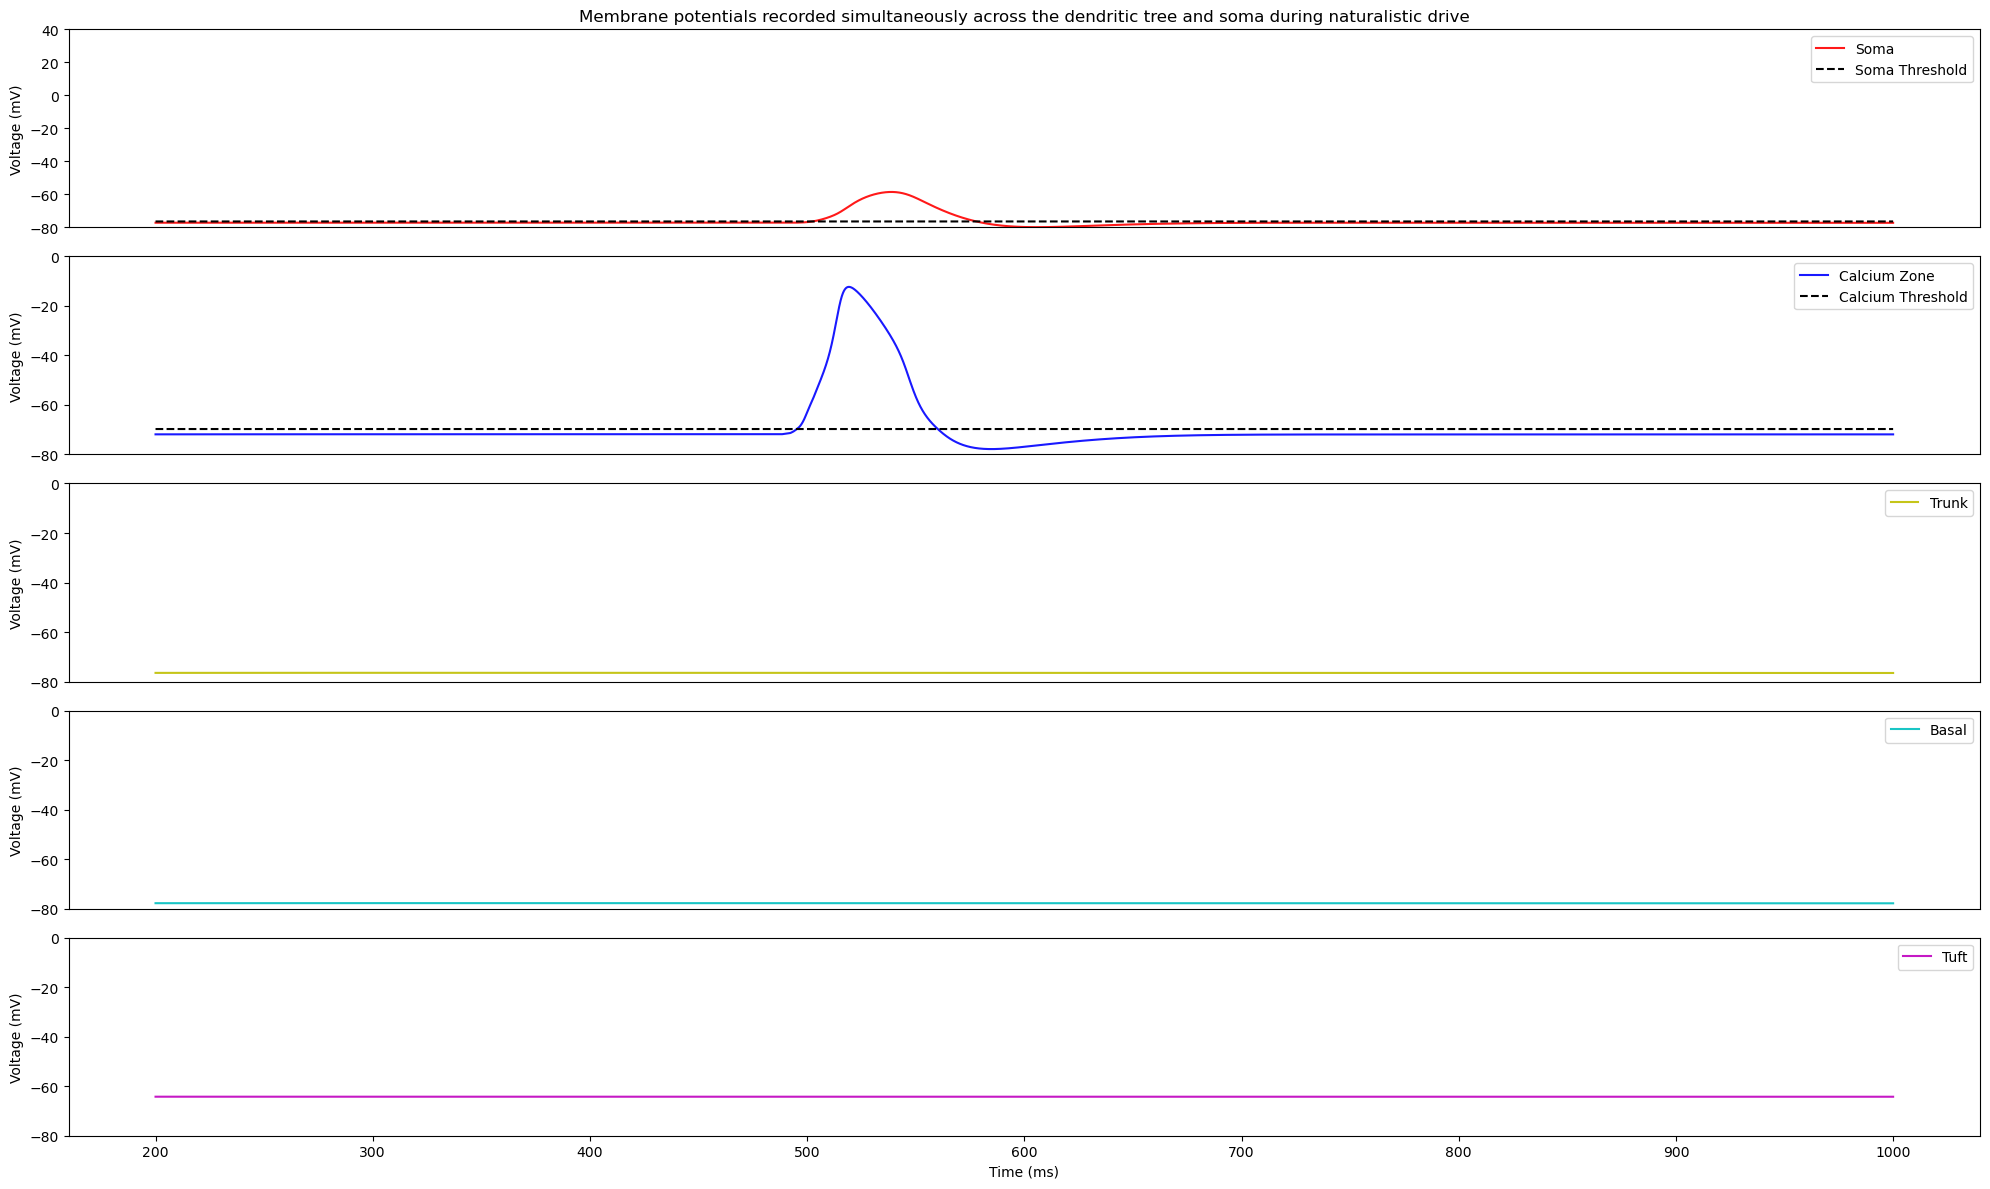

In [223]:
def visualization(exp, fig_idx, trial_idx):
    try:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)
    
    except ValueError:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)
    
    if v.ndim == 5:
        v = np.mean(v, axis=2) # shape: [num_clusters, num_times, num_affs, num_trials]
        soma = np.mean(soma, axis=1) # shape: [num_times, num_affs, num_trials]
        apic_v = np.mean(apic_v, axis=1) # shape: [num_times, num_affs, num_trials]


    t = simu_info['time point of stimulation']
    t_start = t*40-12000
    t_end = t*40+20000
    t_vals = np.arange(t_start, t_end)*dt
    syn_num = -1
    
    # Set up the figure
    plt.figure(fig1.number)

    # Subplot 1: Soma
    ax = plt.subplot(5, 1, 1)  
    plt.title('Membrane potentials recorded simultaneously across the dendritic tree and soma during naturalistic drive')
    plt.plot(1000 * t_vals, soma[t_start:t_end, syn_num, trial_idx].squeeze(), alpha=0.9, color='r', label='Soma')
    plt.plot(1000 * t_vals, np.mean(soma[t_start:t_end, syn_num, :]) * np.ones_like(t_vals), color='k', linestyle='--', label='Soma Threshold')
    plt.ylim(-80, 40)
    plt.legend(loc='upper right')
    plt.ylabel('Voltage (mV)')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # Subplot 2: Calcium Zone
    ax = plt.subplot(5, 1, 2) 
    plt.plot(1000 * t_vals, apic_v[t_start:t_end, syn_num, trial_idx].squeeze(), alpha=0.9, color='b', label='Calcium Zone')
    plt.plot(1000 * t_vals, np.mean(apic_v[t_start:t_end, syn_num, :]) * np.ones_like(t_vals), color='k', linestyle='--', label='Calcium Threshold')
    plt.ylim(-80, 0)
    plt.legend(loc='upper right')
    plt.ylabel('Voltage (mV)')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # Subplot 3: Trunk 
    ax = plt.subplot(5, 1, 3)  
    plt.plot(1000 * t_vals, trunk_v[t_start:t_end, syn_num, trial_idx].squeeze(), alpha=0.9, color='y', label='Trunk')
    plt.ylim(-80, 0)
    plt.legend(loc='upper right')
    plt.ylabel('Voltage (mV)')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # Subplot 4: Basal 
    ax = plt.subplot(5, 1, 4)  
    plt.plot(1000 * t_vals, basal_v[t_start:t_end, syn_num, trial_idx].squeeze(), alpha=0.9, color='c', label='Basal')
    plt.ylim(-80, 0)
    plt.legend(loc='upper right')
    plt.ylabel('Voltage (mV)')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # Subplot 5: Tuft 
    plt.subplot(5, 1, 5)  
    plt.plot(1000 * t_vals, tuft_v[t_start:t_end, syn_num, trial_idx].squeeze(), alpha=0.9, color='m', label='Tuft')
    plt.ylim(-80, 0)
    plt.legend(loc='upper right')
    plt.ylabel('Voltage (mV)')
    plt.xlabel('Time (ms)')

    print(np.mean(apic_v[t_start:t_end, syn_num, :]) - np.mean(soma[t_start:t_end, syn_num, :]))

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # # create path
    # if not os.path.exists('D:/results/simulation/pseudo/figures'):
    #     os.makedirs('D:/results/simulation/pseudo/figures')

    # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'spontaneous voltage.pdf')

    # # Set up the figure
    # plt.figure(fig2.number)

    # # Subplot 1: Calcium Current
    # ax = plt.subplot(5, 1, 1)  
    # plt.title('Dendritic spike events recorded simultaneously across the dendritic tree during naturalistic drive')
    # plt.plot(1000 * t_vals, 1000 * apic_ica[t_start:t_end, syn_num, trial_idx].squeeze(), alpha=0.9, color='b', label='Calcium')
    # plt.ylabel('Current (pA)')
    # plt.ylim(-5, 0.5)
    # plt.legend(loc='lower right')
    # ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # # Subplot 2: Basal background NMDA
    # ax = plt.subplot(5, 1, 2)  
    # plt.plot(1000 * t_vals, 1000 * basal_bg_i_nmda[t_start:t_end, syn_num, trial_idx], color='c', label='Basal bg NMDA')
    # plt.ylabel('Current (pA)')
    # plt.ylim(-100, 0.5)
    # plt.legend(loc='lower right')
    # ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # # Subplot 3: Basal background AMPA
    # ax = plt.subplot(5, 1, 3)  
    # plt.plot(1000 * t_vals, 1000 * basal_bg_i_ampa[t_start:t_end, syn_num, trial_idx], color='orange', label='Basal bg AMPA')
    # plt.ylabel('Current (pA)')
    # plt.ylim(-100, 0.5)
    # plt.legend(loc='lower right')
    # ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  
    
    # # Subplot 4: Tuft background NMDA
    # ax = plt.subplot(5, 1, 4)  
    # plt.plot(1000 * t_vals, 1000 * tuft_bg_i_nmda[t_start:t_end, syn_num, trial_idx], color='m', label='Tuft bg NMDA')
    # plt.ylabel('Current (pA)')
    # plt.ylim(-30, 0.5)
    # plt.legend(loc='lower right')
    # ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  

    # # Subplot 5: Tuft background AMPA
    # plt.subplot(5, 1, 5)  
    # plt.plot(1000 * t_vals, 1000 * tuft_bg_i_ampa[t_start:t_end, syn_num, trial_idx], color='green', label='Tuft bg AMPA')
    # plt.ylabel('Current (pA)')
    # plt.xlabel('Time (ms)')
    # plt.ylim(-40, 0.5)
    # plt.legend(loc='lower right')
    
    # # # Adjust layout to prevent overlap
    # # plt.tight_layout()

    # # # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'spontaneous current.pdf')

for trial_idx in range(1):
    fig1 = plt.figure(figsize=(20,12))
    fig2 = plt.figure(figsize=(20,12))
    for i in range(17, 18):
        visualization('20241029_1059/%d/' % i, i, trial_idx)     

## Distance Analysis

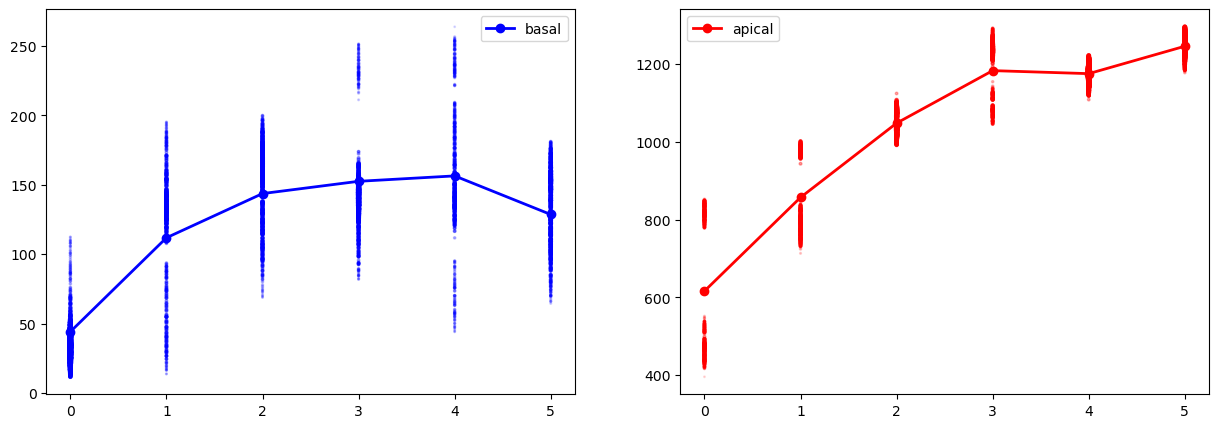

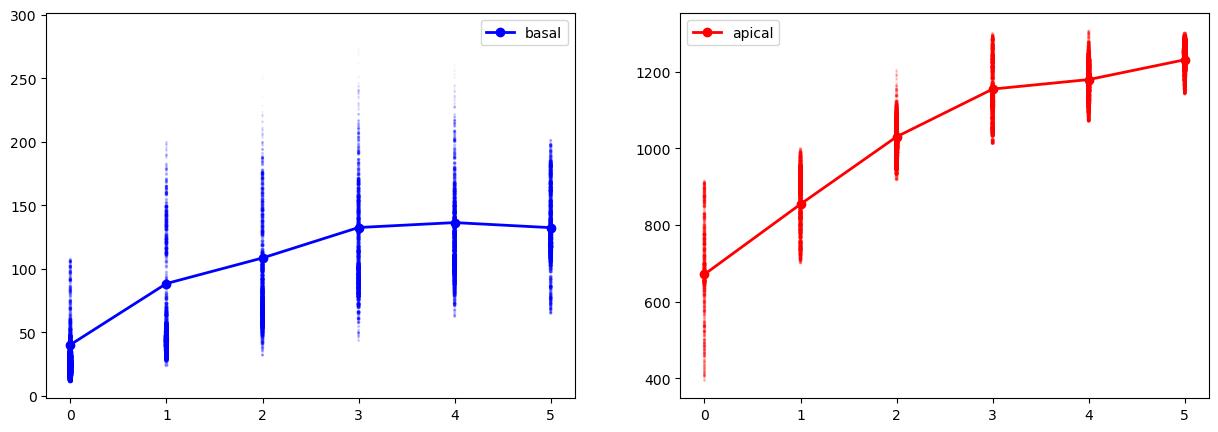

In [7]:
# Read distance from each sec_syn_df, draw the scatter plot (y: distance, x: order)
# Clus/Dispersed basal/apical vitro
from scipy.stats import gaussian_kde

root_folder_path = '/G/results/simulation/'
Exps = ['20241029_1121/', '20241029_1524/']

for Exp in Exps:
    # read subfolders in the folder
    num_subfolders = count_subfolders(root_folder_path, Exp)

    plt.subplots(1, 2, figsize=(15, 5))
    # combine exp with subfolder
    basal_folders = [Exp + str(i) + '/' for i in range(1, num_subfolders//2+1)]
    apical_folders = [Exp + str(i) + '/' for i in range(num_subfolders//2+1, num_subfolders+1)]

    for folder_idx in range(2):

        clus_orders = []
        clus_dists = []
        sec_types = []
        mean_clus_dists = []
        epoch = 0

        folders = basal_folders if folder_idx == 0 else apical_folders
        for exp in folders:
            try:
                v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, \
                trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
                tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)
            
            except ValueError:
                simu_info, sec_syn_df = load_data(exp)

            # label the distance with order from simu_info
            dis_to_root = simu_info['distance from clusters to root']
            clus_dist = sec_syn_df[sec_syn_df['type']=='C']['cluster_distance'].values
            sec_type = simu_info['section type']

            clus_dists.extend(clus_dist)
            clus_orders.extend([dis_to_root]*len(clus_dist))
            sec_types.extend([sec_type]*len(clus_dist))
            mean_clus_dists.append(np.mean(clus_dist))
            epoch += 1

        # Calculate density
        kde = gaussian_kde(np.vstack([clus_orders, clus_dists]))
        density = kde(np.vstack([clus_orders, clus_dists]))

        # Normalize density for point sizes and transparency
        sizes = 10 * density / np.max(density) # Scale sizes to a reasonable range
        alphas = 1 * density / np.max(density)  # Scale transparencies to a reasonable range

        plt.subplot(1, 2, folder_idx+1)
        # if sec_type is basal, color as blue; apical as red
        colors = ['b' if sec_type == 'basal' else 'r' for sec_type in sec_types]
        plt.plot(range(6), mean_clus_dists, marker='o', linestyle='-', color=colors[0], linewidth=2)
        plt.scatter(clus_orders, clus_dists, c=colors, s=sizes, alpha=alphas)
        plt.legend([sec_types[0]])

### Synergistic effects of *basal* and *apical* inputs

### Nonlinearity Analysis

In [24]:
def analyze_voltage_trace_stimdim(exp):
    V_DUR_THR = 26
    try:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)
    
    except ValueError:
        v, i, nmda, ampa, nmda_g, ampa_g, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)

    if v.ndim == 5:
        v = np.mean(v, axis=2)
        apic_v = np.mean(apic_v, axis=1)
        soma = np.mean(soma, axis=1)

    # Low-pass filt v
    v = np.apply_along_axis(lowpass_filter, axis=1, arr=v) # shape: [num_clusters, num_times, num_affs, num_trials]

    num_preunit = simu_info['number of preunit']
    num_aff_fibers = v.shape[2]
    num_affrents = np.linspace(0, num_preunit, num_aff_fibers) # np.arange(0, num_preunit+5, 5)

    # relationship between prob of NMDA spike and num of afferents in single cluster
    t = simu_info['time point of stimulation']
    t_start = (t-20)*40 # -100 ms
    t_end = (t+100)*40 # 100 ms
    
    nmda_amp_thr = calcium_amp_thr = -40     
    nmda_baseline = np.mean(v[:, (t-200)*40:(t-100)*40, :, :]) # shape: [num_clusters, num_times, num_affs, num_trials]
    calcium_baseline = np.mean(apic_v[(t-200)*40:(t-100)*40, :, :]) # shape: [num_times, num_affs, num_trials]

    ## Local NMDA spikes analysis
    nmda_above_threshold_bools_array = v > nmda_amp_thr # shape: [num_clusters, num_times, num_affs, num_trials]
    prob_nmda_spikes = np.mean(np.apply_along_axis(detect_nmda_spike, axis=1, arr=nmda_above_threshold_bools_array), axis=(0, 2)) # shape: [num_affs]
    
    nmda_over_baseline = np.clip(np.mean(v[:,t_start:t_end, :, :], axis=3) - nmda_baseline, 0, None)
    peak_nmda_spikes = np.mean(np.max(nmda_over_baseline, axis=1), axis=0)
    
    ## Calcium spikes analysis

    # Give wider time window for calcium spikes
    t_start = (t-20)*40 # -100 ms
    t_end = (t+200)*40 # 200 ms
    t_center = (t+100)*40

    calcium_above_threshold_bools_array = apic_v > calcium_amp_thr
    prob_calcium_spikes = np.mean(np.apply_along_axis(detect_calcium_spike, axis=0, arr=calcium_above_threshold_bools_array), axis=1) # shape: [num_affs]

    aligned_apic_v = align_calcium_voltage_trace(apic_v, t_start, t_end, t_center)

    calcium_over_baseline = np.clip(np.mean(aligned_apic_v[t_start:t_end, :, :], axis=2) - calcium_baseline, 0, None)
    peak_calcium_spikes = np.max(calcium_over_baseline, axis=0)

    ## Soma AP analysis
    t_start = (t-100)*40
    t_end = (t+100)*40

    binsize = 400
    soma_firing_rate_peak = soma_bin_peak(soma[t_start:t_end, :, :], binsize, dt) # soma: [num_times, num_affs, num_trials]

    return peak_nmda_spikes, prob_nmda_spikes, \
           peak_calcium_spikes, prob_calcium_spikes, \
           soma_firing_rate_peak, num_affrents

def nonlinearity_analysis_updated(exp):

    root_folder_path = '/G/results/simulation/'

    num_folders = count_subfolders(root_folder_path, exp)
    num_basal_folders = num_apical_folders = num_folders #// 2

    area_nmda_spikes_array = np.zeros((num_folders, 41))
    prob_nmda_spikes_array = np.zeros((num_folders, 41))
    area_calcium_spikes_array = np.zeros((num_folders, 41))
    prob_calcium_spikes_array = np.zeros((num_folders, 41))
    soma_firing_rate_array = np.zeros((num_folders, 41))
    num_affrents_array = np.zeros((num_folders, 41))

    # Read the result_df from the exp path, it not exist, do the following loop
    if os.path.exists(root_folder_path+exp+'area_nmda_spikes.npy'):
        area_nmda_spikes_array = np.load(root_folder_path+exp+'area_nmda_spikes.npy')
        prob_nmda_spikes_array = np.load(root_folder_path+exp+'prob_nmda_spikes.npy')
        area_calcium_spikes_array = np.load(root_folder_path+exp+'area_calcium_spikes.npy')
        prob_calcium_spikes_array = np.load(root_folder_path+exp+'prob_calcium_spikes.npy')
        soma_firing_rate_array = np.load(root_folder_path+exp+'soma_firing_rate.npy')
        num_affrents_array = np.load(root_folder_path+exp+'num_affrents.npy')

    else:
        for folder_idx in range(1, num_folders+1):
            area_nmda_spikes, prob_nmda_spikes, \
            area_calcium_spikes, prob_calcium_spikes, \
            soma_firing_rate, num_affrents = analyze_voltage_trace_stimdim(exp+str(folder_idx)+'/')
            
            # save each as a row in the dataframe
            area_nmda_spikes_array[folder_idx-1] = area_nmda_spikes
            prob_nmda_spikes_array[folder_idx-1] = prob_nmda_spikes
            area_calcium_spikes_array[folder_idx-1] = area_calcium_spikes
            prob_calcium_spikes_array[folder_idx-1] = prob_calcium_spikes
            soma_firing_rate_array[folder_idx-1] = soma_firing_rate
            num_affrents_array[folder_idx-1] = num_affrents

        np.save(root_folder_path+exp+'area_nmda_spikes.npy', area_nmda_spikes_array)
        np.save(root_folder_path+exp+'prob_nmda_spikes.npy', prob_nmda_spikes_array)
        np.save(root_folder_path+exp+'area_calcium_spikes.npy', area_calcium_spikes_array)
        np.save(root_folder_path+exp+'prob_calcium_spikes.npy', prob_calcium_spikes_array)
        np.save(root_folder_path+exp+'soma_firing_rate.npy', soma_firing_rate_array)
        np.save(root_folder_path+exp+'num_affrents.npy', num_affrents_array)

    # Colors from matplotlib
    cmap_sky_to_dark = plt.get_cmap('Blues')  # Blues colormap
    cmap_yellow_to_red = plt.get_cmap('YlOrRd')  # Yellow to Red colormap

    # Generating color series
    basal_colors = [cmap_sky_to_dark(i) for i in np.linspace(0.2, 1, num_basal_folders)]
    apical_colors = [cmap_yellow_to_red(i) for i in np.linspace(0.1, 1, num_basal_folders)]

    # 1 2 3 draw together (Basal)
    # fig 1: NMDA prob
    # fig 2: NMDA area
    # fig 3: soma firing rate

    # plt.figure(figsize=(4, 5))
    # plt.tight_layout()
    # for basal_idx in range(num_basal_folders):
    #     try:
    #         basal_area_nmda_spikes = area_nmda_spikes_array[basal_idx]
    #         # basal_prob_nmda_spikes = prob_nmda_spikes_array[basal_idx]
    #         # basal_soma_firing_rate = soma_firing_rate_array[basal_idx]
    #         num_affrents = num_affrents_array[basal_idx]

    #         with open(os.path.join(root_folder_path, exp, str(basal_idx+1), 'simulation_params.json')) as f:
    #             simu_info = json.load(f)

    #         dis_to_root = simu_info['distance from clusters to root']
            
    #         ax1 = plt.subplot(1, 1, 1)
    #         ax1.spines['top'].set_visible(False)
    #         ax1.spines['right'].set_visible(False)
    #         ax1.set_ylim(0, 80)
    #         ax1.set_xlim(0, 80)
    #         ax1.set_yticks([0, 20, 40, 60, 80])
    #         ax1.set_xticks([0, 20, 40, 60, 80])
    #         ax1.plot(num_affrents, basal_area_nmda_spikes, color=basal_colors[basal_idx], label=f'Basal NMDA amp {dis_to_root}', linewidth=2)
    #         ax1.legend(fontsize=6,loc='upper left')

    #         # ax2 = plt.subplot(1, 3, 2)
    #         # ax2.spines['top'].set_visible(False)
    #         # ax2.spines['right'].set_visible(False)
    #         # ax2.set_ylim(0, 1.05)
    #         # ax2.plot(num_affrents, basal_prob_nmda_spikes, color=basal_colors[basal_idx], label=f'P(Basal NMDA) {dis_to_root}', linewidth=2)

    #         # ax3 = plt.subplot(1, 3, 3)
    #         # ax3.spines['top'].set_visible(False)
    #         # ax3.spines['right'].set_visible(False)
    #         # ax3.set_ylim(0, 105)
    #         # ax3.plot(num_affrents, basal_soma_firing_rate, color=basal_colors[basal_idx], label=f'Basal soma firing rate {dis_to_root}', linewidth=2)
    #         # # ax3.plot(num_affrents, sigmoid(num_affrents, *params), color=basal_colors[basal_idx], label=f'Fitted Sigmoid {dis_to_root}', linestyle='--', linewidth=2)

    #     except FileNotFoundError:
    #         pass

    # ax1.set_xlabel('Number of activated afferents')
    # ax1.set_ylabel('Amplitude of NMDA spikes')

    # # create path
    # # if not os.path.exists('D:/results/simulation/pseudo/figures/'+exp):
    # #     os.makedirs('D:/results/simulation/pseudo/figures/'+exp)

    # # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Basal_Peak_NMDA.pdf')

    # def basal_stack_visualization(attr_array, ylim):
    #     for basal_idx in range(num_basal_folders):
    #         basal_prob_nmda_spikes = attr_array[num_basal_folders-basal_idx-1]
    #         num_affrents = num_affrents_array[num_basal_folders-basal_idx-1]
            
    #         axes[basal_idx].spines['top'].set_visible(False)
    #         axes[basal_idx].spines['right'].set_visible(False)
    #         # axes[basal_idx].text(-0.03, 1.2*(basal_idx/num_basal_folders), str(basal_idx+1), transform=axes[basal_idx].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')
    #         if basal_idx != num_basal_folders-1:
    #             axes[basal_idx].set_xticks([])
    #         if basal_idx == num_basal_folders-1:
    #             axes[basal_idx].set_xticks([0, 20, 40, 60, 80])
    #             axes[basal_idx].set_xlabel('Number of activated afferents')
                
    #         axes[basal_idx].plot(num_affrents, basal_prob_nmda_spikes, color=basal_colors[num_basal_folders-basal_idx-1], linewidth=2)
    #         axes[basal_idx].fill_between(num_affrents, 0, basal_prob_nmda_spikes, color=basal_colors[num_basal_folders-basal_idx-1], alpha=0.3)
    #         axes[basal_idx].set_xlim(0, 80)
    #         axes[basal_idx].set_ylim(0, ylim+0.01)
    #         axes[basal_idx].set_yticks([0, ylim])
    #         # axes[basal_idx].set_yticklabels([0, ylim])

    # # Previous ax2, ax3
    # for i in range(2):
    #     fig, axes = plt.subplots(num_basal_folders, 1, figsize=(4, 5))
    #     fig.subplots_adjust(wspace=0)

    #     if i == 0:
    #         basal_stack_visualization(prob_nmda_spikes_array, 1)
    #         # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Basal_Prob_NMDA.pdf')
    #     elif i == 1:
    #         basal_stack_visualization(soma_firing_rate_array, 100)
    #         # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Basal_Freq_Soma.pdf')

    # # # 4 5 6 draw together (Apical)
    # # # fig 4: NMDA prob
    # # # fig 5: NMDA area
    # # # fig 6: calcium prob
    # # # fig 7: calcium area
    # # # fig 8: soma firing rate

    plt.figure(figsize=(4, 5))
    plt.tight_layout()
    for apical_idx in range(num_apical_folders): #, num_folders):
        try:
            apical_area_nmda_spikes = area_nmda_spikes_array[apical_idx]
            num_affrents = num_affrents_array[apical_idx]

            with open(os.path.join(root_folder_path, exp, str(apical_idx+1), 'simulation_params.json')) as f:
                simu_info = json.load(f)

            dis_to_root = simu_info['distance from clusters to root']

            ax1 = plt.subplot(1, 1, 1)
            ax1.spines['top'].set_visible(False)
            ax1.spines['right'].set_visible(False)
            ax1.set_ylim(0, 80)
            ax1.set_xlim(0, 80)
            ax1.set_yticks([0, 20, 40, 60, 80])
            ax1.set_xticks([0, 20, 40, 60, 80])
            ax1.plot(num_affrents, apical_area_nmda_spikes, color=apical_colors[apical_idx-num_apical_folders], label=f'Apical NMDA amp {dis_to_root}', linewidth=2)
            ax1.legend(fontsize=6,loc='upper left')

        except FileNotFoundError:
            pass
    
    # ax1.set_title(f'Num of aff vs Amp of NMDA spikes')
    ax1.set_xlabel('Number of activated afferents')
    ax1.set_ylabel('Amplitude of NMDA spikes')
    # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Apical_Peak_NMDA.pdf')

    def apical_stack_visualization(attr_array, ylim):
        for apical_idx in range(num_apical_folders):
            basal_prob_nmda_spikes = attr_array[num_folders-apical_idx-1]
            num_affrents = num_affrents_array[num_folders-apical_idx-1]
            
            axes[apical_idx].spines['top'].set_visible(False)
            axes[apical_idx].spines['right'].set_visible(False)
            if apical_idx != num_apical_folders-1:
                axes[apical_idx].set_xticks([])
            if apical_idx == num_apical_folders-1:
                axes[apical_idx].set_xticks([0, 20, 40, 60, 80])
                axes[apical_idx].set_xlabel('Number of activated afferents')

            axes[apical_idx].plot(num_affrents, basal_prob_nmda_spikes, color=apical_colors[num_apical_folders-apical_idx-1], linewidth=2)
            axes[apical_idx].fill_between(num_affrents, 0, basal_prob_nmda_spikes, color=apical_colors[num_apical_folders-apical_idx-1], alpha=0.3)
            axes[apical_idx].set_xlim(0, 80)
            axes[apical_idx].set_ylim(0, ylim+0.01)
            axes[apical_idx].set_yticks([0, ylim])
        
    for i in range(3):
        fig, axes = plt.subplots(num_apical_folders, 1, figsize=(4, 5))
        fig.subplots_adjust(wspace=0)
        if i == 0:
            apical_stack_visualization(prob_nmda_spikes_array, 1)
            # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Apical_Prob_NMDA.pdf')
        elif i == 1:
            apical_stack_visualization(prob_calcium_spikes_array, 1)
            # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Apical_Prob_Ca2+.pdf')
        elif i == 2:
            apical_stack_visualization(soma_firing_rate_array, 100)
            # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'Apical_Freq_Soma.pdf')
        
    # # # Compare basal vs apical
    # # # fig 9: basal 2nd vs apical 2nd NMDA prob & area
    # # # fig 10: basal 3rd vs apical 3rd NMDA prob & area
    # # # fig 11: basal 4th vs apical 4th NMDA prob & area

    # plt.figure(figsize=(4*num_basal_folders, 10))
    # plt.tight_layout()
    # for basal_idx in range(num_basal_folders):
    #     try:
    #         basal_area_nmda_spikes = area_nmda_spikes_array[basal_idx]
    #         basal_prob_nmda_spikes = prob_nmda_spikes_array[basal_idx]
    #         # basal_soma_firing_rate = soma_firing_rate_array[basal_idx]
    #         num_affrents = num_affrents_array[basal_idx]
            
    #         apical_area_nmda_spikes = area_nmda_spikes_array[basal_idx+num_basal_folders]
    #         apical_prob_nmda_spikes = prob_nmda_spikes_array[basal_idx+num_basal_folders]
    #         # apical_area_calcium_spikes = area_calcium_spikes_array[basal_idx+num_basal_folders]
    #         # apical_prob_calcium_spikes = prob_calcium_spikes_array[basal_idx+num_basal_folders]
    #         # apical_soma_firing_rate = soma_firing_rate_array[basal_idx+num_basal_folders]

    #         with open(os.path.join(root_folder_path, exp, str(basal_idx+1), 'simulation_params.json')) as f:
    #             simu_info = json.load(f)

    #         dis_to_root = simu_info['distance from clusters to root']

    #         ax1 = plt.subplot(2, num_basal_folders, basal_idx+1)
    #         ax1.spines['top'].set_visible(False)
    #         ax1.spines['right'].set_visible(False)
    #         ax1.set_xlim(0, 80)
    #         ax1.set_ylim(0, 80)
    #         ax1.set_xticks([0, 20, 40, 60, 80])
    #         ax1.set_yticks([0, 20, 40, 60, 80])
    #         ax1.plot(num_affrents, basal_area_nmda_spikes, color=basal_colors[basal_idx], label=f'Basal NMDA amp {dis_to_root}', linewidth=2)    
    #         ax1.plot(num_affrents, apical_area_nmda_spikes, color=apical_colors[basal_idx], label=f'Apical NMDA amp {dis_to_root}', linewidth=2)
            
    #         ax1.legend(fontsize=6,loc='upper left')
    #         # ax1.set_title(f'Num of aff vs Amp of NMDA spikes (order: {dis_to_root})')

    #         ax2 = plt.subplot(2, num_basal_folders, basal_idx+1+num_basal_folders)
    #         ax2.spines['top'].set_visible(False)
    #         ax2.spines['right'].set_visible(False)
    #         ax1.set_xlim(0, 80)
    #         ax2.set_ylim(0, 1)
    #         ax2.set_xticks([0, 20, 40, 60, 80])
    #         ax2.set_yticks([0, 0.5, 1])
    #         ax2.plot(num_affrents, basal_prob_nmda_spikes, color=basal_colors[basal_idx], label=f'Basal NMDA prob {dis_to_root}', linewidth=2)
    #         ax2.plot(num_affrents, apical_prob_nmda_spikes, color=apical_colors[basal_idx], label=f'Apical NMDA prob {dis_to_root}', linewidth=2)

    #         # ax2.set_title(f'Num of aff vs Prob of NMDA spikes (order: {dis_to_root})')
    #         ax2.set_xlabel('Number of activated afferents')

    #         if basal_idx == 0:
    #             ax1.set_ylabel('Amplitude of NMDA spikes')
    #             ax2.set_ylabel('Probability of NMDA spikes')
            
    #     except FileNotFoundError:
    #         pass

    # # Save
    # # plt.savefig('D:/results/simulation/pseudo/figures/'+exp+'nonlinearity_analysis_basal&apical.pdf')

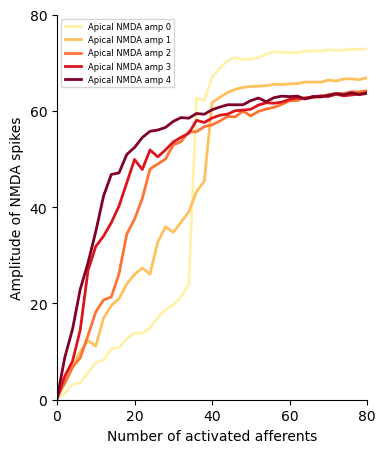

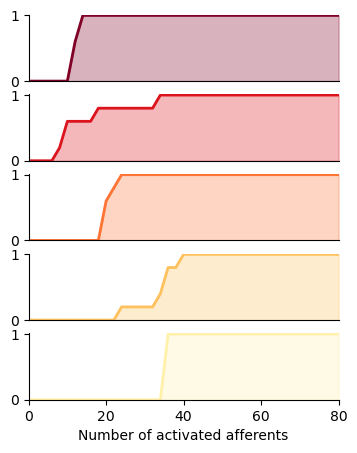

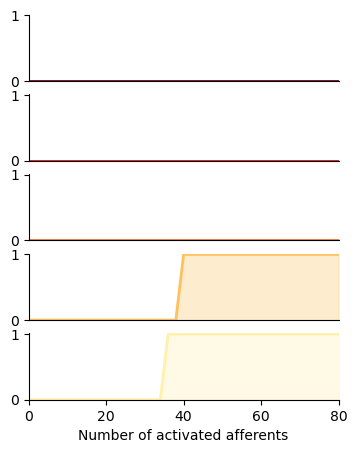

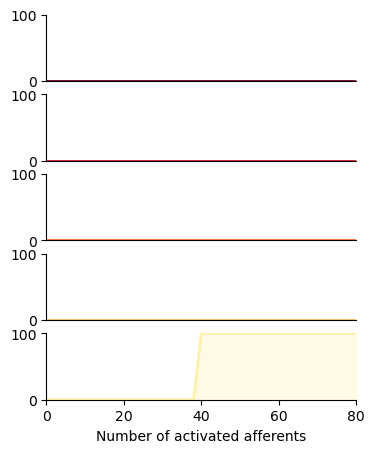

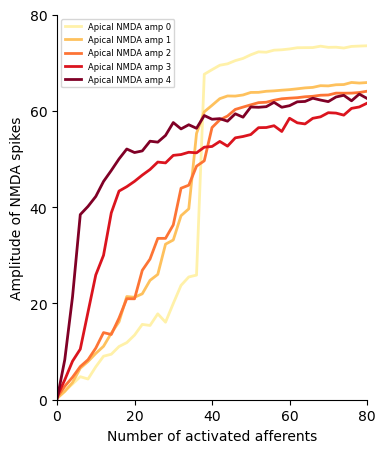

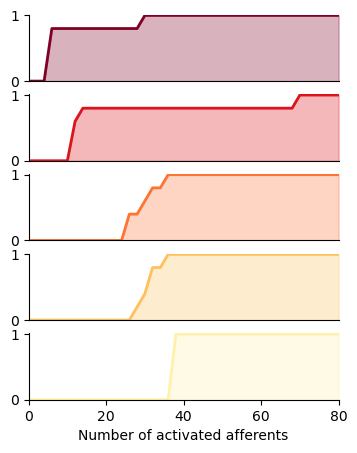

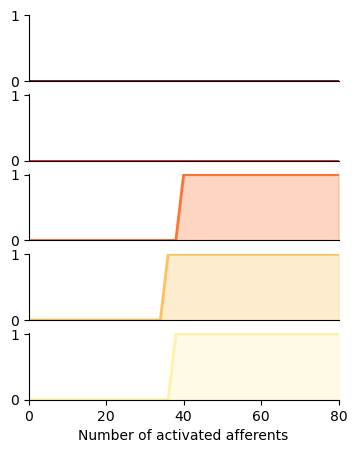

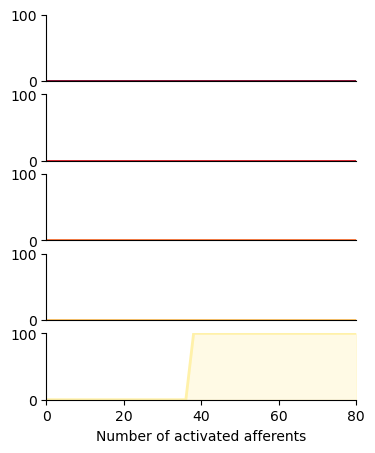

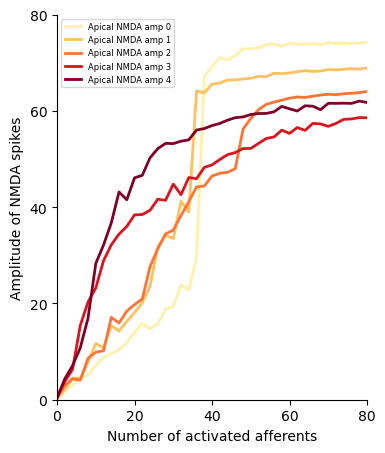

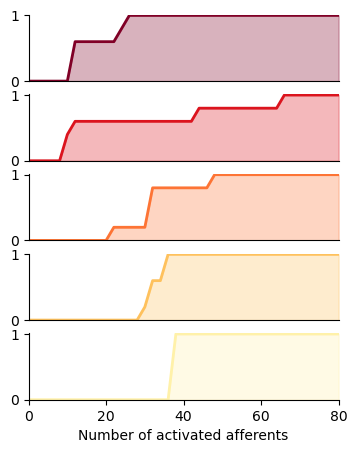

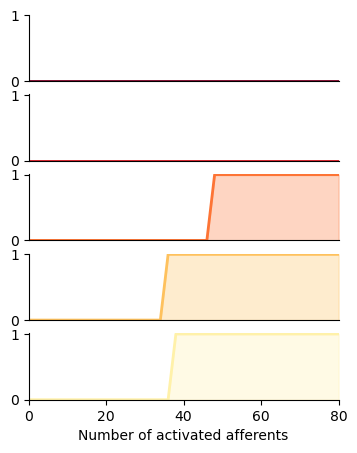

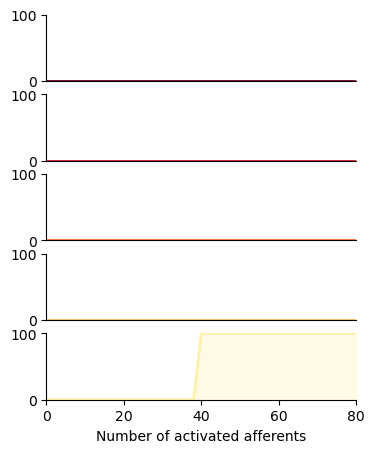

In [27]:
nonlinearity_analysis_updated('20241105_1519/')
nonlinearity_analysis_updated('20241105_2038/')
nonlinearity_analysis_updated('20241105_1542/')

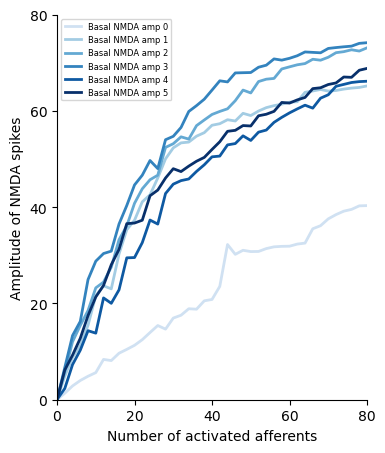

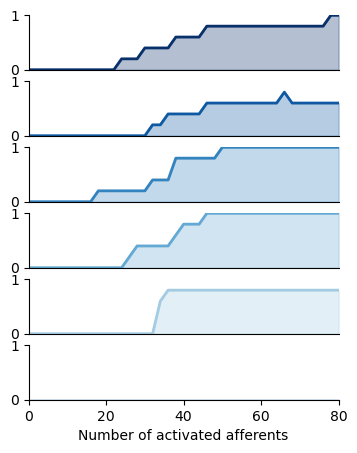

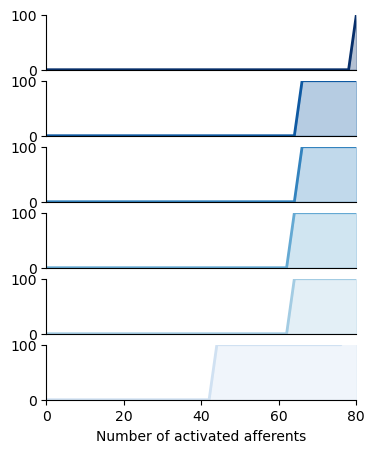

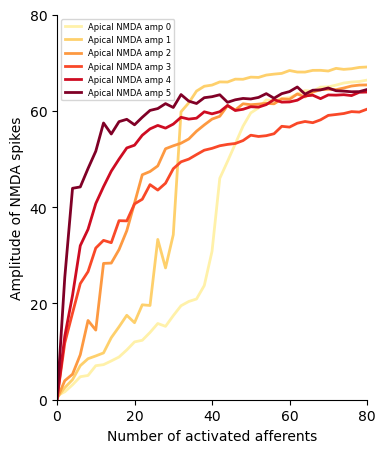

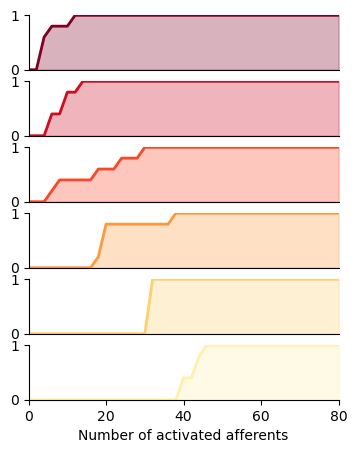

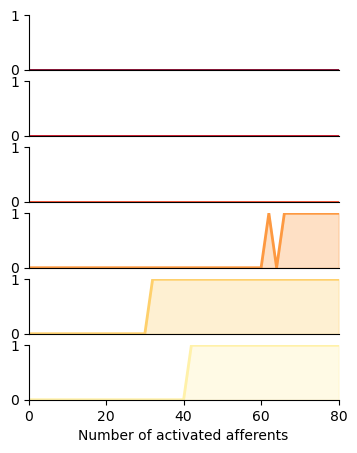

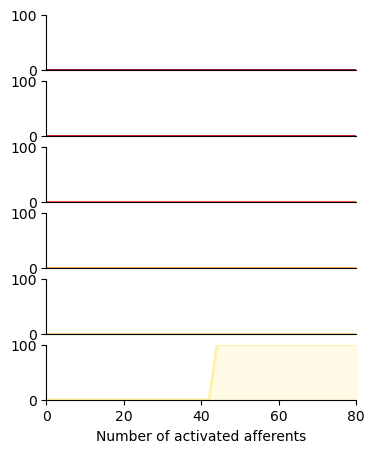

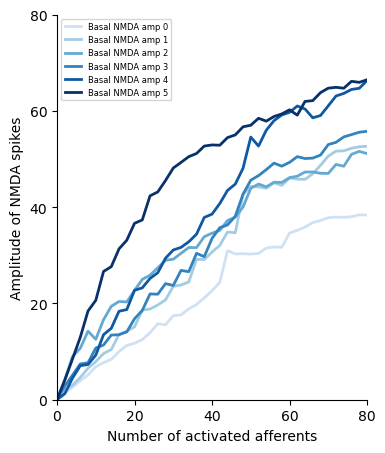

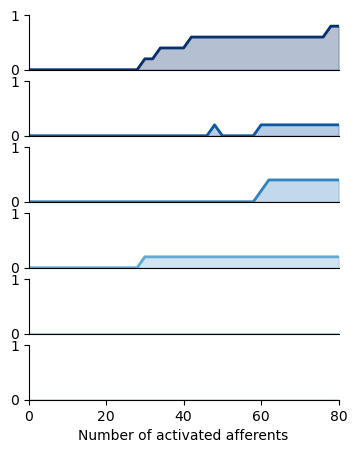

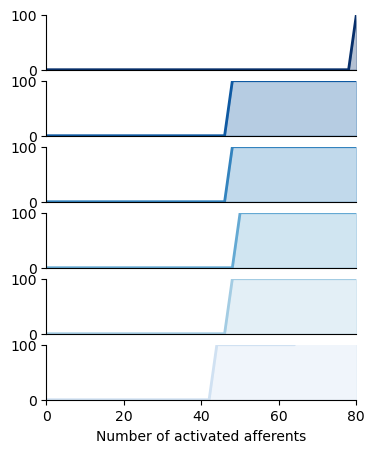

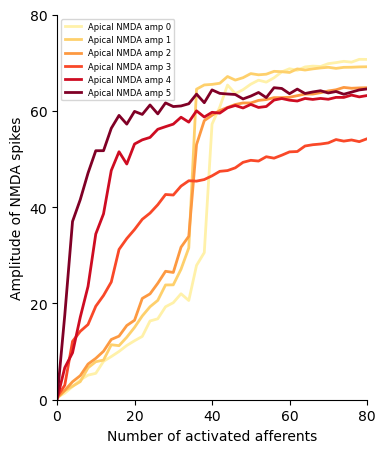

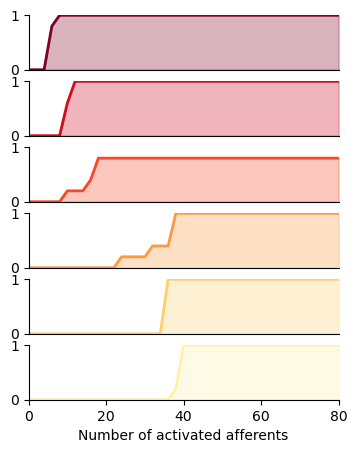

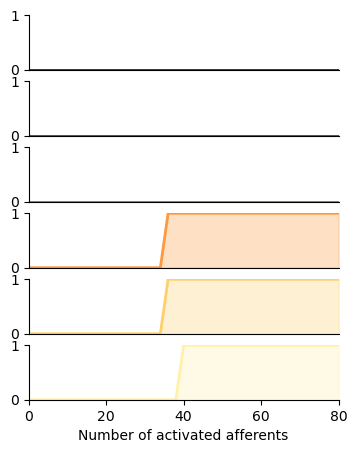

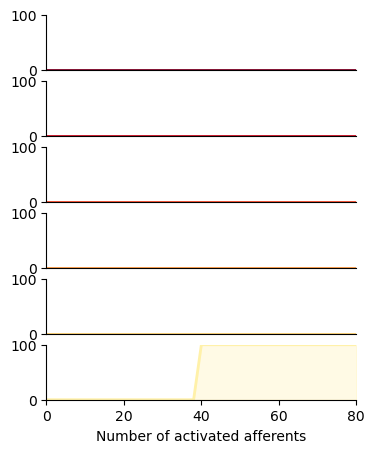

In [19]:
nonlinearity_analysis_updated('20241029_1121/')
nonlinearity_analysis_updated('20241030_1009/')

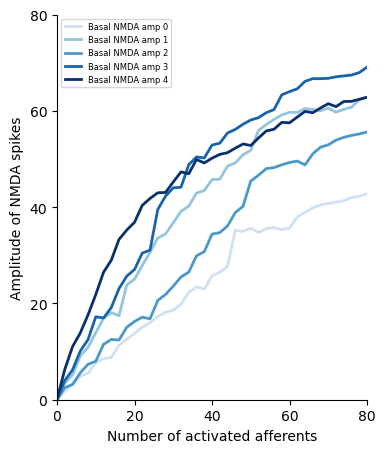

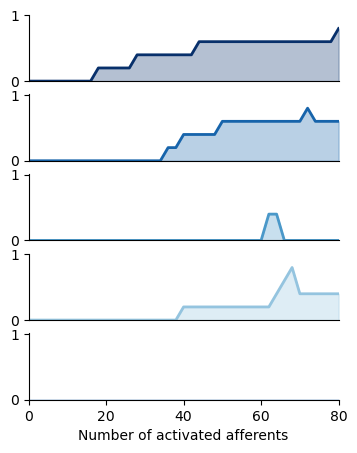

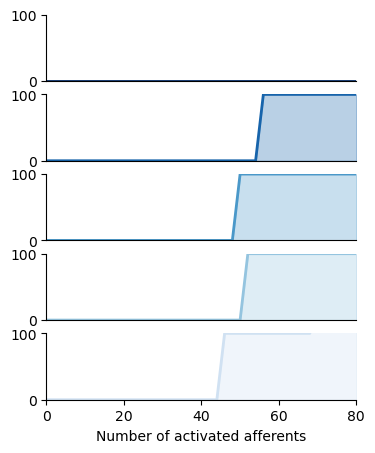

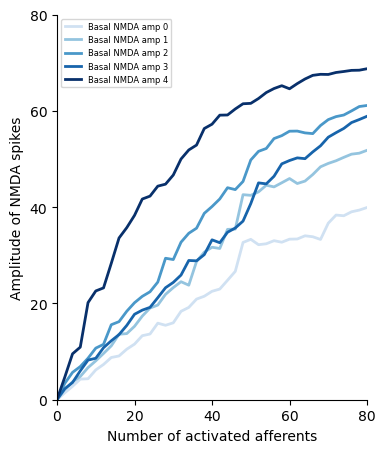

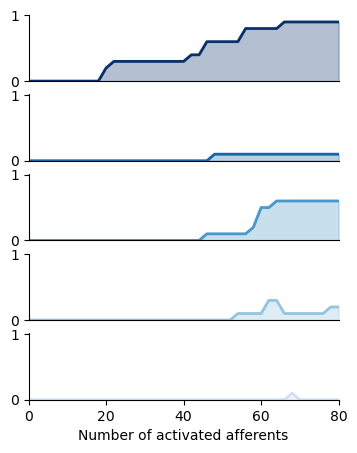

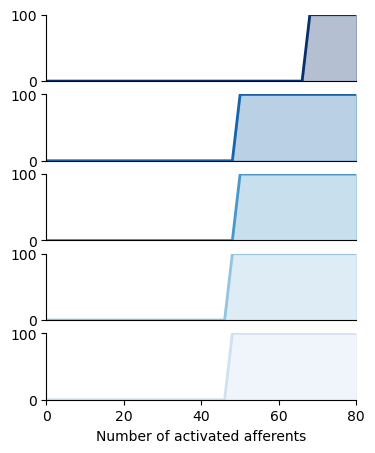

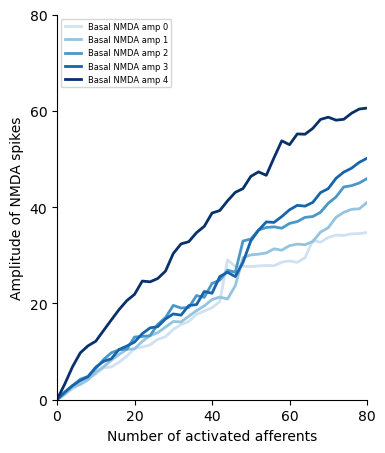

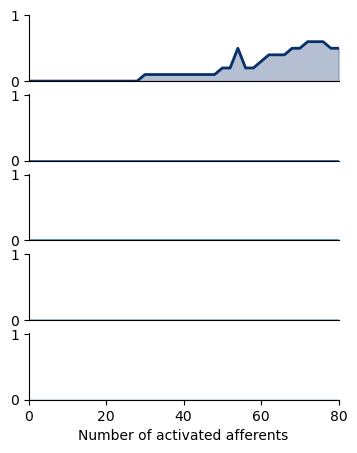

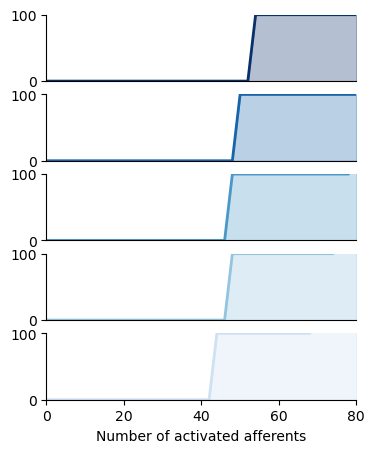

In [17]:
nonlinearity_analysis_updated('20241105_1130/')
nonlinearity_analysis_updated('20241105_1035/')
nonlinearity_analysis_updated('20241105_1055/')

In [154]:
def detect_nmda_spike(voltage, current):
    """
    Detect NMDA spike based on voltage and current criteria.
    
    :param voltage: Array of voltage values (in mV)
    :param current: Array of current values (in pA or any consistent unit)
    :param time_interval: Time interval between consecutive measurements (in ms)
    :return: Boolean indicating if an NMDA spike was detected
    """
    time_interval = 1000 / 40000

    # Find indices where voltage crosses -40 mV
    crossing_indices = np.where(voltage > -40)[0]
    
    if len(crossing_indices) == 0:
        return False  # No voltage crossing detected
    
    # Find segments where voltage stays above -40 mV for at least 26 ms
    spike_detected = False
    for i in range(len(crossing_indices)):
        start_idx = crossing_indices[i]
        end_idx = start_idx
        while end_idx < len(voltage) and voltage[end_idx] > -40:
            end_idx += 1
        
        duration_above_threshold = (end_idx - start_idx) * time_interval
        
        if duration_above_threshold >= 26:
            # spike_detected = True
            # Voltage criteria met, now check current criteria
            current_at_threshold = current[start_idx]
            current_threshold_130 = 1.3 * current_at_threshold
            current_threshold_115 = 1.15 * current_at_threshold
            
            # Check if current exceeds 130% and then falls to 115%
            above_130 = np.where(current[start_idx:end_idx] > current_threshold_130)[0]
            if len(above_130) > 0:
                spike_detected = True
                # above_130_idx = start_idx + above_130[0]
                # for j in range(above_130_idx, end_idx):
                #     if current[j] < current_threshold_115:
                #         spike_detected = True
                #         break
                if spike_detected:
                    break
    
    return spike_detected

In [451]:
def test(exp, syn_num, clus_idx):

    V_DUR_THR = 26

    try:
        v, i, nmda, ampa, soma, apic_v, apic_ica, \
        trunk_v, basal_v, tuft_v, basal_bg_i_nmda, basal_bg_i_ampa, \
        tuft_bg_i_nmda, tuft_bg_i_ampa, dt, simu_info, sec_syn_df = load_data(exp)
    
    except ValueError:
        v, i, nmda, ampa, soma, apic_v, apic_ica, dt, simu_info = load_data(exp)
    
    if v.ndim == 5:
        v = np.mean(v, axis=2)
        apic_v = np.mean(apic_v, axis=1)
        soma = np.mean(soma, axis=1)
        r, a Chair of the committee (not the adviser), at least 2 other BNS facu
    dis_to_root = simu_info['distance from clusters to root']
    num_stim = simu_info['number of stimuli']
    num_preunit = simu_info['number of preunit']
    t = simu_info['time point of stimulation']
    sec_type = simu_info['section type']
    
    clus_ctr_syn = sec_syn_df[sec_syn_df['is_cluster_center']==1]['segment_synapse'].values
    clus_ctr_dis = np.round(sec_syn_df[sec_syn_df['is_cluster_center']==1]['cluster_distance'].values,2)

    # if simu_info['section type'] == 'basal':
    #     t_start = t*40-4000 # basal: -50~50 ms
    #     t_end = t*40+4000
    #     t_center = t*40

    # elif simu_info['section type'] == 'apical':
    #     t_start = t*40 # apical: 0~100 ms
    #     t_end = t*40+8000
    #     t_center = t*40+4000
   
    nmda_baseline = np.mean(v[:, (t*40-10000):(t*40-5000), :, :])
    calcium_baseline = np.mean(apic_v[(t*40-10000):(t*40-5000), :, :])
    nmda_amp_thr = calcium_amp_thr = -40
    
    # nmda_above_threshold_bools_array = v[:, t_start:t_end, :, :] > nmda_amp_thr
    # num_times = 1000 / 40000 * np.apply_along_axis(find_longest_continuous_ones, axis=1, arr=nmda_above_threshold_bools_array)
    # prob_nmda_spikes = np.mean(num_times > V_DUR_THR, axis=(0, 2)) # average across #clus and #trial

    # calcium_above_threshold_bools_array = apic_v[t_start:t_end, :, :] > calcium_amp_thr
    # num_times_apical = 1000 / 40000 * np.apply_along_axis(find_longest_continuous_ones, axis=0, arr=calcium_above_threshold_bools_array)
    # prob_calcium_spikes = np.mean(num_times_apical > V_DUR_THR, axis=1) # average across #trial
 
    # x = np.arange(0, t_end-t_start)*dt

    # nmda_positive = np.clip(v[:,t_start:t_end, :, :] - nmda_amp_thr, 0, None)
    # calcium_positive = np.clip(apic_v[t_start:t_end, :, :] - calcium_amp_thr, 0, None)
    # area_nmda_spikes = np.trapz(nmda_positive, x, axis=1) # np.mean(np.trapz(nmda_positive, x, axis=1), axis=(0, 2))
    # area_calcium_spikes = np.trapz(calcium_positive, x, axis=0) # np.mean(np.trapz(calcium_positive, x, axis=0), axis=1)
    
    # nmda_positive = np.clip(np.mean(v[:,t_start:t_end, :, :], axis=3) - nmda_amp_thr, 0, None)
    # aligned_apic_v = align_calcium_voltage_trace(apic_v, t_start, t_end, t_center)
    # calcium_positive = np.clip(np.mean(aligned_apic_v[t_start:t_end, :, :], axis=2) - calcium_amp_thr, 0, None)
    # calcium_positive_ori = np.clip(np.mean(apic_v[t_start:t_end, :, :], axis=2) - calcium_amp_thr, 0, None)
    
    # area_nmda_spikes = np.mean(np.trapz(nmda_positive, x, axis=1), axis=0)
    # area_calcium_spikes = np.trapz(calcium_positive, x, axis=0)
    # area_calcium_spikes_ori = np.trapz(calcium_positive_ori, x, axis=0)

    t_start = (t-50)*40
    t_end = (t+150)*40
    t_vals = np.arange(t_start, t_end)*dt-t/1000

    # plt.figure(figsize=(21,8))r, a Chair of the committee (not the adviser), at least 2 other BNS facu
    plt.figure(figsize=(4, 4))
    # plt.suptitle(exp+f' order to root: {dis_to_root}, number of stimuli: {num_stim})')
    # plt.subplot(1,2,1)
    # plt.title(f'Cluster {clus_idx+1}, Distance: {clus_ctr_dis[clus_idx]}\n{clus_ctr_syn[clus_idx]}')
    # Remove right and top spines
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.xlim(-50,150)
    plt.xticks([-50, 0, 50, 100, 150])
    plt.ylim(-80,0)
    plt.yticks([-80, -60, -40, -20, 0])
    # plt.ylabel('Voltage (mV)')
    plt.xlabel('Time from afferent burst peak (ms)')
    # plt.plot(1000*t_vals, nmda_baseline*np.ones_like(t_vals), color='k', linestyle='dashdot', label='NMDA Basline')
    # plt.plot(1000*t_vals, nmda_amp_thr*np.ones_like(t_vals), color='k', linestyle='--', label='NMDA Threshold')
    plt.plot(1000*t_vals, v[clus_idx, t_start:t_end, syn_num, :].squeeze(), alpha=0.2, linewidth=0.7)
    if sec_type == 'basal':
        color = '#00AEEF'
    elif sec_type == 'apical':
        color = '#ED1C24'
    plt.plot(1000*t_vals, np.mean(v[clus_idx, t_start:t_end, syn_num, :], axis=1), color=color, label='NMDA', linewidth=1.5)
    # plt.legend()
    
    # Save figure
    if os.path.exists('D:/results/simulation/pseudo/figures/'+exp) == False:
        os.makedirs('D:/results/simulation/pseudo/figures/'+exp)

    plt.savefig('D:/results/simulation/pseudo/figures/'+exp+f'Cluster_{clus_idx+1}_Syn_{syn_num}_NMDA_Voltage.pdf')

    if sec_type == 'apical':
        plt.figure(figsize=(4, 4))
        # plt.subplot(1,2,2)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.xlim(-50,150)
        plt.xticks([-50, 0, 50, 100, 150])
        plt.ylim(-80,0)
        plt.yticks([-80, -60, -40, -20, 0])
        plt.xlabel('Time from afferent burst peak (ms)')
        # draw a line at -40 mV 
        # plt.plot(1000*t_vals, calcium_baseline*np.ones_like(t_vals), color='k', linestyle='dashdot', label='Calcium Basline')
        # plt.plot(1000*t_vals, calcium_amp_thr*np.ones_like(t_vals), color='k', linestyle='--', label='Calcium Threshold')
        plt.plot(1000*t_vals, apic_v[t_start:t_end, syn_num, :].squeeze(), alpha=0.2, linewidth=0.7)
        plt.plot(1000*t_vals, np.mean(apic_v[t_start:t_end, syn_num, :], axis=1), color='#FBB040', label='Calcium', linewidth=1.5)
        # plt.legend()

        # Save figure
        if os.path.exists('D:/results/simulation/pseudo/figures/'+exp) == False:
            os.makedirs('D:/results/simulation/pseudo/figures/'+exp)

        plt.savefig('D:/results/simulation/pseudo/figures/'+exp+f'Cluster_{clus_idx+1}_Syn_{syn_num}_Ca2+_Voltage.pdf')


    # plt.subplot(2,3,3)
    # plt.gca().spines['right'].set_visible(False)
    # plt.gca().spines['top'].set_visible(False)
    # plt.ylim(-80,20)
    # # draw a line at -40 mV 
    # plt.plot(1000*t_vals, calcium_baseline*np.ones_like(t_vals), color='k', linestyle='dashdot', label='Calcium Basline')
    # plt.plot(1000*t_vals, calcium_amp_thr*np.ones_like(t_vals), color='k', linestyle='--', label='Calcium Threshold')
    # plt.plot(1000*t_vals, aligned_apic_v[t_start:t_end, syn_num, :].squeeze(), alpha=0.3)
    # plt.plot(1000*t_vals, np.mean(aligned_apic_v[t_start:t_end, syn_num, :], axis=1), color='b', label='Calcium')
    # plt.legend()
    
    # num_aff_fibers = v.shape[2]
    # num_affrents = np.linspace(0, int(num_preunit/1), int(num_aff_fibers/1)) 
    
    # ax1 = plt.subplot(2,3,4)
    # # ax1.set_ylim(0, 1.5)
    # ax1.plot(num_affrents, area_nmda_spikes, color='r', label='NMDA Area')
    # ax1.plot(num_affrents, area_calcium_spikes, color='b', label='Calcium Area')
    # ax1.plot(num_affrents, area_calcium_spikes_ori, color = 'g', label='Calcium Area Original')
    # ax1.legend(loc='upper right')
    # # ax2 = ax1.twinx()
    # # ax2.set_ylim(0, 1.05)
    # # # ax2.plot(num_affrents, prob_nmda_spikes, color='g', label='NMDA Probablity')
    # # # ax2.plot(num_affrents, prob_calcium_spikes, color='y', label='Calcium Probablity')
    # # ax2.legend(loc='upper left')

    # Visualize Soma AP
    # plt.subplot(2,3,5)
    # plt.gca().spines['right'].set_visible(False)
    # plt.gca().spines['top'].set_visible(False)
    # plt.ylim(-80,40)
    # plt.plot(1000*t_vals, soma[t_start:t_end, syn_num, :].squeeze(), alpha=0.3)
    # plt.plot(1000*t_vals, np.mean(soma[t_start:t_end, syn_num, :], axis=1), color='b', label='Soma')
    
    # for trial_idx in range(soma.shape[2]):
    #     peaks, _ = find_peaks(soma[t_start:t_end, syn_num, trial_idx], height=0)
    #     peaks_time = 1000/40000 * (peaks + t_start) - t
    #     plt.plot(peaks_time, soma[t_start:t_end, syn_num, trial_idx][peaks], "x")

    # plt.plot(1000*t_vals, 0*np.ones_like(t_vals), color='k', linestyle='--', label='Threshold')
    # plt.legend()

    # Visualize soma firing rate difference
    # plt.subplot(2,3,6)
    # binsize = 400
    # peak_firing_rate = soma_bin_peak(soma[t_start:t_end, :, :], binsize, dt)
    # plt.plot(num_affrents, peak_firing_rate, color='b', label='Soma Firing Rate')

    # if simu_info['section type'] == 'basal':
    #     t_start = t*40-4000 # basal: -50~50 ms
    #     t_end = t*40+4000

    # elif simu_info['section type'] == 'apical':
    #     t_start = t*40 # apical: 0~100 ms
    #     t_end = t*40+8000

    # num_soma_ap = np.mean(np.apply_along_axis(find_num_peaks, axis=0, arr=soma[t_start:t_end, :, :]), axis=1) 
    # pre_num_soma_ap = np.mean(np.apply_along_axis(find_num_peaks, axis=0, arr=soma[t_start-8000:t_end-8000, :, :]), axis=1) 
    # post_num_soma_ap = np.mean(np.apply_along_axis(find_num_peaks, axis=0, arr=soma[t_start+8000:t_end+8000, :, :]), axis=1) 
    
    # soma_firing_rate = num_soma_ap /(8000/40000)
    # soma_firing_rate_baseline = (pre_num_soma_ap /(8000/40000) + post_num_soma_ap /(8000/40000))/2
    
    # plt.plot(num_affrents, soma_firing_rate, color='b', label='Soma Firing Rate')
    # plt.plot(num_affrents, soma_firing_rate_baseline, color='r', label='Soma Firing Rate Baseline')
    # plt.plot(num_affrents, np.mean(soma_firing_rate_baseline)*np.ones_like(num_affrents), color='k', linestyle='--', label='Baseline')    
    # plt.legend()